# 🥇 Gold vs US Dollar Index — Relationship Analysis (2000–2025)

> **Objective:** Examine the relationship between Gold prices and the US Dollar Index, with special focus on abnormal years (2008, 2020, 2022) and months. Includes outlier detection, time-series analysis, lag analysis, and full statistical tests.

---

**Table of Contents**
1. [Data Import & Cleaning](#1)
2. [Exploratory Data Analysis & Summary Statistics](#2)
3. [Outlier & Anomaly Detection](#3)
4. [Time Series Visualizations](#4)
5. [Abnormal Periods — Highlighted Graphs](#5)
6. [Correlation Analysis](#6)
7. [Regression Analysis](#7)
8. [Lag Analysis & Cross-Correlation](#8)
9. [Stationarity & Cointegration Tests](#9)
10. [Granger Causality Test](#10)
11. [Key Findings & Conclusions](#11)

In [1]:
# ─── IMPORTS ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kendalltau

# ── Optional: statsmodels (install with: pip install statsmodels) ──────────────
try:
    from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests, ccf
    from statsmodels.tsa.api import VAR
    from statsmodels.regression.linear_model import OLS
    from statsmodels.tools import add_constant
    from statsmodels.stats.stattools import durbin_watson
    from statsmodels.tsa.stattools import coint
    STATSMODELS = True
    print('✅ statsmodels loaded')
except ImportError:
    STATSMODELS = False
    print('⚠️  statsmodels not found — ADF, KPSS, Granger, Cointegration tests will be skipped.')
    print('   Install with: pip install statsmodels')

# ── Style ─────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
GOLD   = '#D4AF37'
BLUE   = '#1F4E79'
RED    = '#C0392B'
GREEN  = '#1ABC9C'
ORANGE = '#E67E22'

pd.set_option('display.float_format', '{:.4f}'.format)
print('✅ All libraries imported successfully')

✅ statsmodels loaded
✅ All libraries imported successfully


<a id='1'></a>
## 1. Data Import & Cleaning

Replace the synthetic block below with the real yfinance download when running in your environment.

In [2]:
# ─── OPTION A: Real data via yfinance (uncomment when yfinance is installed) ──
import yfinance as yf
tickers = ['GC=F', 'DX-Y.NYB']
print('Fetching data from Yahoo Finance...')
data = yf.download(tickers, start='2000-01-01', interval='1mo')
df = data['Close'].copy()
df.rename(columns={'DX-Y.NYB': 'USD_Index', 'GC=F': 'Gold_Price'}, inplace=True)
df.dropna(inplace=True)
df.index = pd.to_datetime(df.index)


print(f'✅ Dataset loaded — {len(df)} monthly observations')
print(f'   Period: {df.index[0].strftime("%b %Y")} → {df.index[-1].strftime("%b %Y")}')

Fetching data from Yahoo Finance...


[*********************100%***********************]  2 of 2 completed

✅ Dataset loaded — 264 monthly observations
   Period: Aug 2000 → May 2026


In [3]:
# ─── CLEANING & DERIVED COLUMNS ───────────────────────────────────────────────
df['Gold_Return']  = df['Gold_Price'].pct_change() * 100   # % monthly return
df['USD_Return']   = df['USD_Index'].pct_change()  * 100
df['Gold_LogRet']  = np.log(df['Gold_Price'] / df['Gold_Price'].shift(1)) * 100
df['USD_LogRet']   = np.log(df['USD_Index']  / df['USD_Index'].shift(1))  * 100
df['Gold_Norm']    = df['Gold_Price'] / df['Gold_Price'].iloc[0] * 100   # base-100
df['USD_Norm']     = df['USD_Index']  / df['USD_Index'].iloc[0]  * 100
df['Year']         = df.index.year
df['Month']        = df.index.month
df.dropna(inplace=True)

print('Dataframe shape:', df.shape)
df.head()

Dataframe shape: (263, 10)


Ticker,USD_Index,Gold_Price,Gold_Return,USD_Return,Gold_LogRet,USD_LogRet,Gold_Norm,USD_Norm,Year,Month
Date,,,,,,,,,,
2000-09-01,113.2500,273.6000,-1.6888,0.5773,-1.7032,0.5756,98.3112,100.5773,2000,9
2000-11-01,115.2400,270.1000,-1.2792,1.7572,-1.2875,1.7419,97.0535,102.3446,2000,11
2000-12-01,109.5600,272.0000,0.7034,-4.9288,0.7010,-5.0545,97.7363,97.3002,2000,12
2001-01-01,110.5200,265.6000,-2.3529,0.8762,-2.3811,0.8724,95.4366,98.1528,2001,1
2001-02-01,112.0100,266.8000,0.4518,1.3482,0.4508,1.3392,95.8678,99.4760,2001,2


<a id='2'></a>
## 2. Exploratory Data Analysis & Summary Statistics

In [4]:
print('=' * 65)
print('  DESCRIPTIVE STATISTICS')
print('=' * 65)
print(df[['Gold_Price', 'USD_Index', 'Gold_Return', 'USD_Return']].describe().round(4).to_string())

print('\n' + '=' * 65)
print('  SKEWNESS & KURTOSIS')
print('=' * 65)
for col in ['Gold_Return', 'USD_Return']:
    sk = df[col].skew()
    ku = df[col].kurtosis()
    print(f'  {col:20s}  Skewness={sk:+.4f}   Excess Kurtosis={ku:+.4f}')

print('\n' + '=' * 65)
print('  NORMALITY TEST — Shapiro-Wilk (p-value)')
print('=' * 65)
for col in ['Gold_Return', 'USD_Return']:
    stat, p = stats.shapiro(df[col].dropna())
    flag = '✅ Normal' if p > 0.05 else '❌ Not Normal'
    print(f'  {col:20s}  stat={stat:.4f}  p={p:.6f}  → {flag}')

  DESCRIPTIVE STATISTICS
Ticker  Gold_Price  USD_Index  Gold_Return  USD_Return
count     263.0000   263.0000     263.0000    263.0000
mean     1298.5350    92.4671       1.1852     -0.0213
std       820.8433    11.2012       4.9293      2.3063
min       257.9000    71.8000     -18.0050     -6.1084
25%       651.9000    82.4050      -1.9776     -1.4588
50%      1266.1000    93.0100       0.9527      0.0000
75%      1711.8500    99.3110       4.3504      1.2339
max      4713.8999   120.2400      16.2563      7.7785

  SKEWNESS & KURTOSIS
  Gold_Return           Skewness=-0.0635   Excess Kurtosis=+0.5993
  USD_Return            Skewness=+0.1194   Excess Kurtosis=+0.6119

  NORMALITY TEST — Shapiro-Wilk (p-value)
  Gold_Return           stat=0.9933  p=0.289804  → ✅ Normal
  USD_Return            stat=0.9890  p=0.043296  → ❌ Not Normal


In [5]:
# ─── Annual summary table ─────────────────────────────────────────────────────
annual = df.groupby('Year').agg(
    Gold_Mean  = ('Gold_Price', 'mean'),
    Gold_Ret   = ('Gold_Return', 'mean'),
    USD_Mean   = ('USD_Index', 'mean'),
    USD_Ret    = ('USD_Return', 'mean'),
    Corr       = ('Gold_Return', lambda x: x.corr(df.loc[x.index, 'USD_Return']))
).round(3)

# Flag abnormal years
abnormal_years = [2008, 2020, 2022]
annual['Abnormal'] = annual.index.isin(abnormal_years)

print('Annual Summary (avg monthly return & correlation):')
print(annual.to_string())

Annual Summary (avg monthly return & correlation):
      Gold_Mean  Gold_Ret  USD_Mean  USD_Ret    Corr  Abnormal
Year                                                          
2000   271.9000   -0.7550  112.6830  -0.8650 -0.9470     False
2001   272.5100    0.2930  115.3040   0.6640 -0.3900     False
2002   308.0700    1.3350  111.8570  -0.8990  0.0300     False
2003   370.0090    2.6600   95.1670  -1.7820 -0.6570     False
2004   413.0100    0.6300   86.7940  -0.7000 -0.7230     False
2005   451.5820    1.5900   87.5430   1.1190 -0.1790     False
2006   619.2000    2.2260   85.8850  -0.8340 -0.8160     False
2007   711.8400    2.8440   80.3170  -0.8640 -0.4840     False
2008   872.2820    0.9460   77.2360   0.5990 -0.6470      True
2009   974.6890    2.5180   79.8330  -0.4410 -0.0880     False
2010  1236.8270    2.4680   81.1940   0.1880  0.0150     False
2011  1577.5450    1.1770   76.2750   0.1670 -0.6400     False
2012  1678.2440    0.8580   80.3760  -0.0360 -0.7600     False
2013

<a id='3'></a>
## 3. Outlier & Anomaly Detection

In [7]:
# ─── Z-Score Outlier Detection ────────────────────────────────────────────────
for col in ['Gold_Return', 'USD_Return']:
    df[f'{col}_zscore'] = np.abs(stats.zscore(df[col].dropna()))

gold_outliers = df[df['Gold_Return_zscore'] > 2][['Gold_Price', 'Gold_Return', 'Gold_Return_zscore']]
usd_outliers  = df[df['USD_Return_zscore']  > 2][['USD_Index',  'USD_Return',  'USD_Return_zscore']]

print(f'Gold outlier months (|z| > 2):  {len(gold_outliers)}')
print(gold_outliers.sort_values('Gold_Return_zscore', ascending=False).head(15).to_string())

print(f'\nUSD outlier months (|z| > 2):  {len(usd_outliers)}')
print(usd_outliers.sort_values('USD_Return_zscore', ascending=False).head(15).to_string())

Gold outlier months (|z| > 2):  10
Ticker      Gold_Price  Gold_Return  Gold_Return_zscore
Date                                                   
2008-10-01    716.8000     -18.0050              3.9005
2003-01-01    368.3000      16.2563              3.0633
2013-06-01   1223.8000     -12.1212              2.7046
2008-11-01    816.2000      13.8672              2.5777
2011-09-01   1620.4000     -11.3809              2.5541
2011-12-01   1565.8000     -10.2950              2.3334
2011-08-01   1828.5000      12.2950              2.2581
2006-04-01    651.8000      12.0316              2.2046
2004-04-01    387.0000      -9.4313              2.1579
2008-08-01    829.3000      -9.2570              2.1225

USD outlier months (|z| > 2):  20
Ticker      USD_Index  USD_Return  USD_Return_zscore
Date                                                
2008-10-01    85.6300      7.7785             3.3884
2003-01-01    99.9100     -6.1084             2.6443
2008-12-01    81.3100     -6.0217             

In [8]:
# ─── IQR-based outlier detection ──────────────────────────────────────────────
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col, label in [('Gold_Return', 'Gold'), ('USD_Return', 'USD')]:
    lo, hi = iqr_bounds(df[col].dropna())
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{label} — IQR bounds: [{lo:.3f}, {hi:.3f}]  |  Outliers: {n_out}')

Gold — IQR bounds: [-11.470, 13.842]  |  Outliers: 4
USD — IQR bounds: [-5.498, 5.273]  |  Outliers: 8


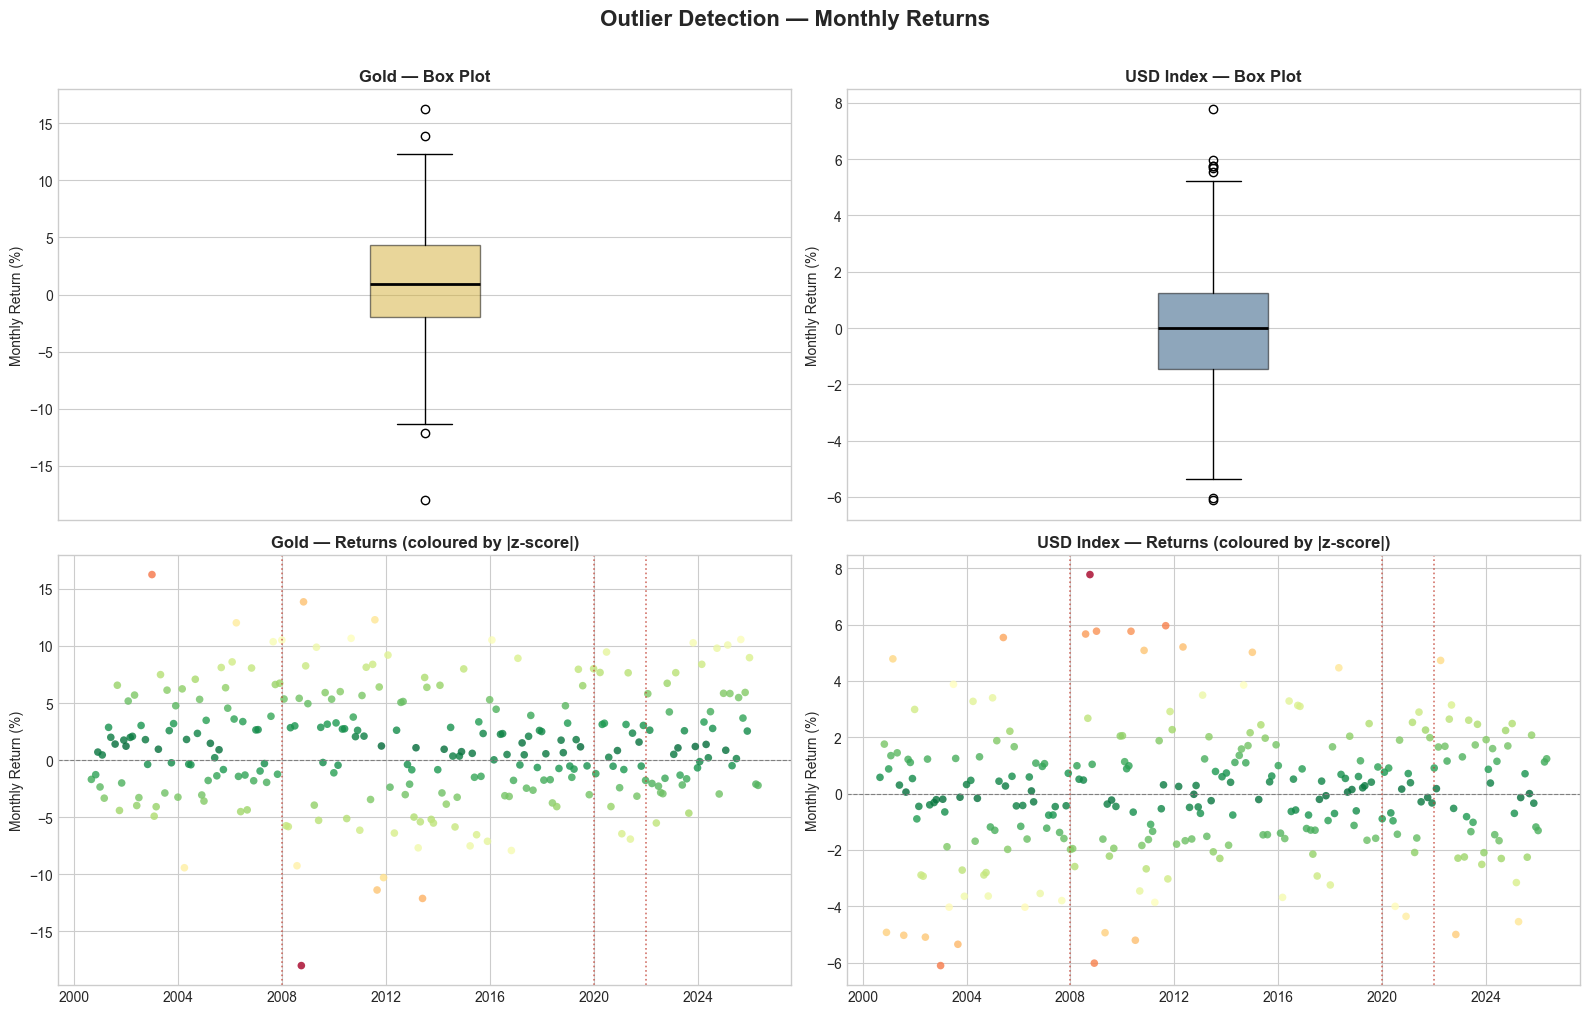

Figure saved → outlier_detection.png


In [9]:
# ─── Outlier Visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Outlier Detection — Monthly Returns', fontsize=16, fontweight='bold', y=1.01)

for ax, col, color, label in zip(
    axes[0], ['Gold_Return', 'USD_Return'],
    [GOLD, BLUE], ['Gold', 'USD Index']):

    data_s = df[col].dropna()
    ax.boxplot(data_s, vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{label} — Box Plot', fontweight='bold')
    ax.set_ylabel('Monthly Return (%)')
    ax.set_xticks([])

for ax, col, color, label in zip(
    axes[1], ['Gold_Return', 'USD_Return'],
    [GOLD, BLUE], ['Gold', 'USD Index']):

    data_s = df[col].dropna()
    zscores = np.abs(stats.zscore(data_s))
    ax.scatter(df.loc[data_s.index, :].index, data_s, c=zscores, cmap='RdYlGn_r',
               s=30, alpha=0.8, edgecolors='none')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    for yr in [2008, 2020, 2022]:
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color=RED, linewidth=1.2,
                   linestyle=':', alpha=0.7, label=str(yr))
    ax.set_title(f'{label} — Returns (coloured by |z-score|)', fontweight='bold')
    ax.set_ylabel('Monthly Return (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → outlier_detection.png')

<a id='4'></a>
## 4. Time Series Visualizations

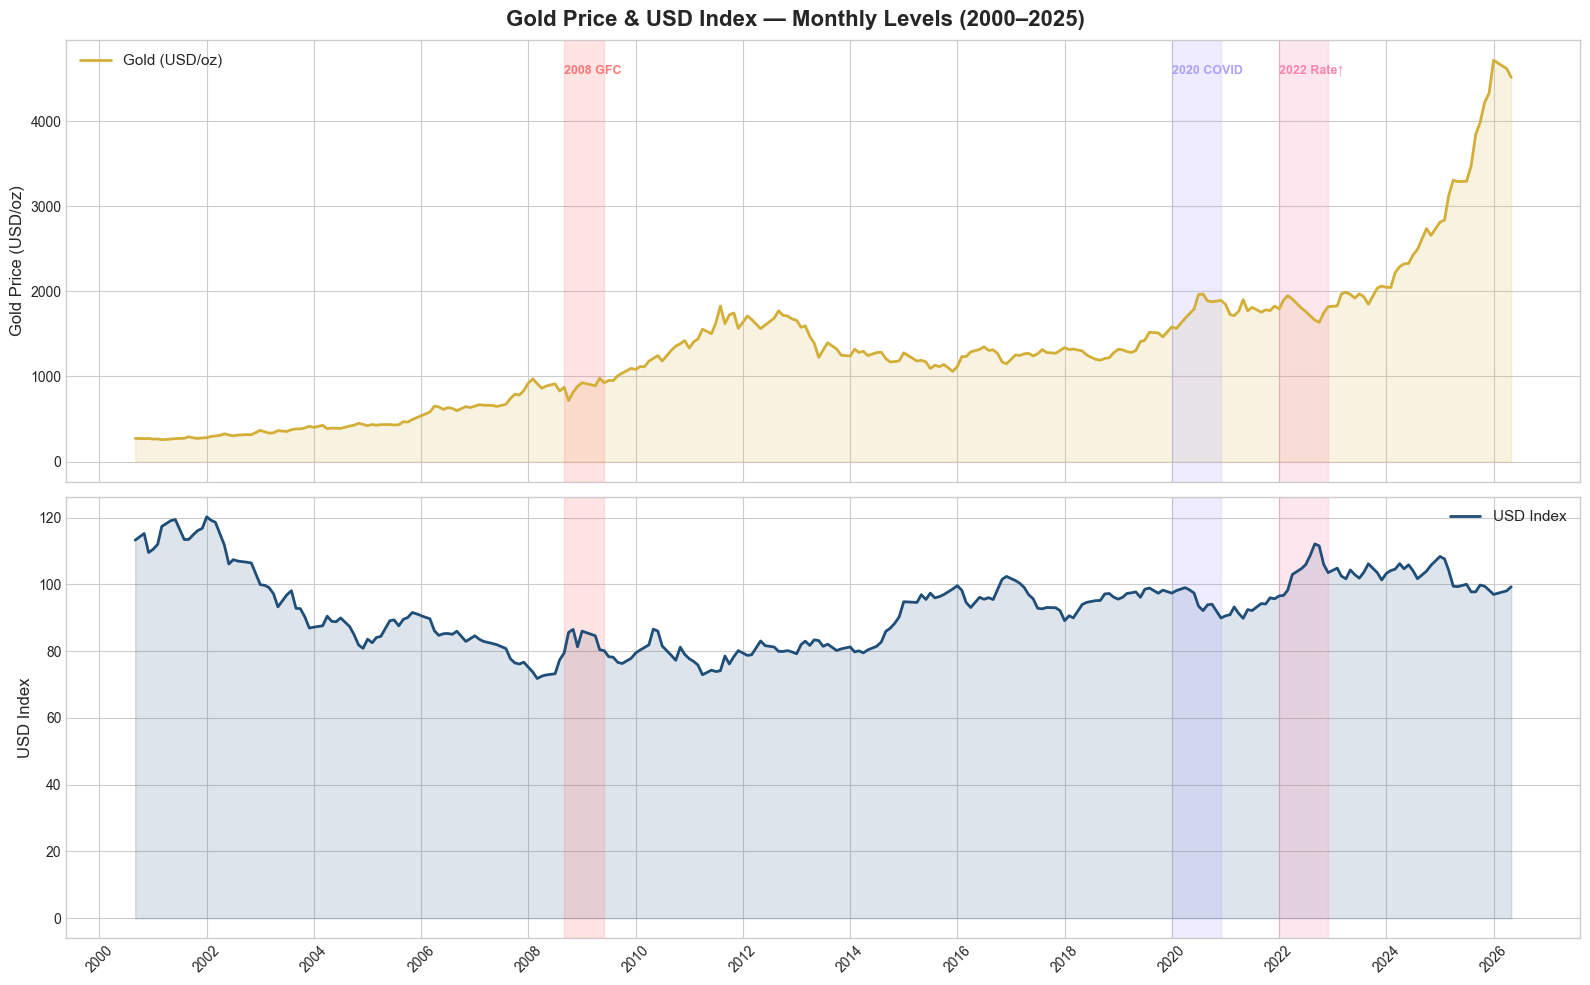

In [10]:
# ─── Price Levels ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Gold Price & USD Index — Monthly Levels (2000–2025)',
             fontsize=16, fontweight='bold')

ax1.plot(df.index, df['Gold_Price'], color=GOLD, linewidth=2, label='Gold (USD/oz)')
ax1.fill_between(df.index, df['Gold_Price'], alpha=0.15, color=GOLD)
ax1.set_ylabel('Gold Price (USD/oz)', fontsize=12)
ax1.legend(fontsize=11)

ax2.plot(df.index, df['USD_Index'], color=BLUE, linewidth=2, label='USD Index')
ax2.fill_between(df.index, df['USD_Index'], alpha=0.15, color=BLUE)
ax2.set_ylabel('USD Index', fontsize=12)
ax2.legend(fontsize=11)

# Shade abnormal periods
crisis_periods = [
    ('2008-09-01', '2009-06-01', '2008 GFC',   '#FF6B6B'),
    ('2020-01-01', '2020-12-01', '2020 COVID',  '#A29BFE'),
    ('2022-01-01', '2022-12-01', '2022 Rate↑',  '#FD79A8'),
]
for start, end, label, col in crisis_periods:
    for ax in [ax1, ax2]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.18, color=col, label=label)
    ax1.text(pd.Timestamp(start), ax1.get_ylim()[1] * 0.92, label,
             fontsize=9, color=col, alpha=0.9, fontweight='bold')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ts_price_levels.png', dpi=150, bbox_inches='tight')
plt.show()

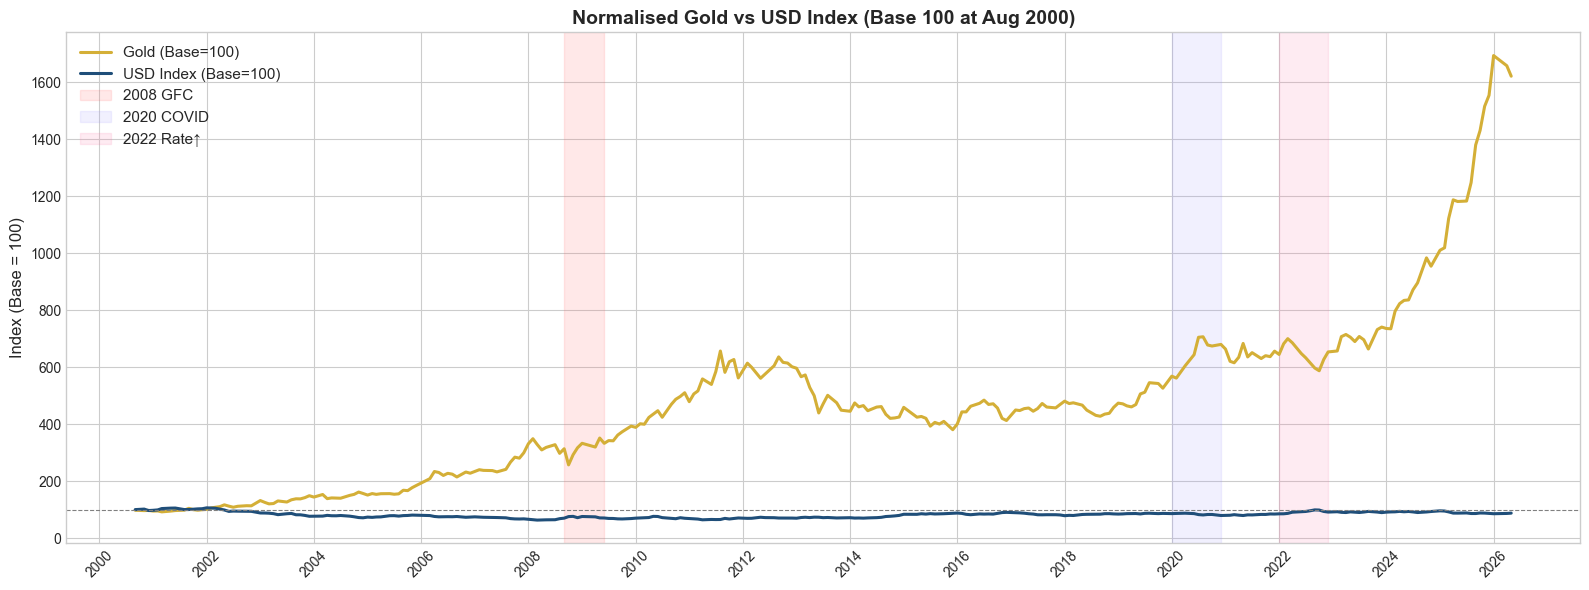

In [11]:
# ─── Normalised (Base 100) Comparison ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, df['Gold_Norm'], color=GOLD, linewidth=2.2, label='Gold (Base=100)')
ax.plot(df.index, df['USD_Norm'],  color=BLUE, linewidth=2.2, label='USD Index (Base=100)')
ax.axhline(100, color='gray', linewidth=0.8, linestyle='--')

for start, end, label, col in crisis_periods:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=col, label=label)

ax.set_title('Normalised Gold vs USD Index (Base 100 at Aug 2000)', fontsize=14, fontweight='bold')
ax.set_ylabel('Index (Base = 100)', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ts_normalised.png', dpi=150, bbox_inches='tight')
plt.show()

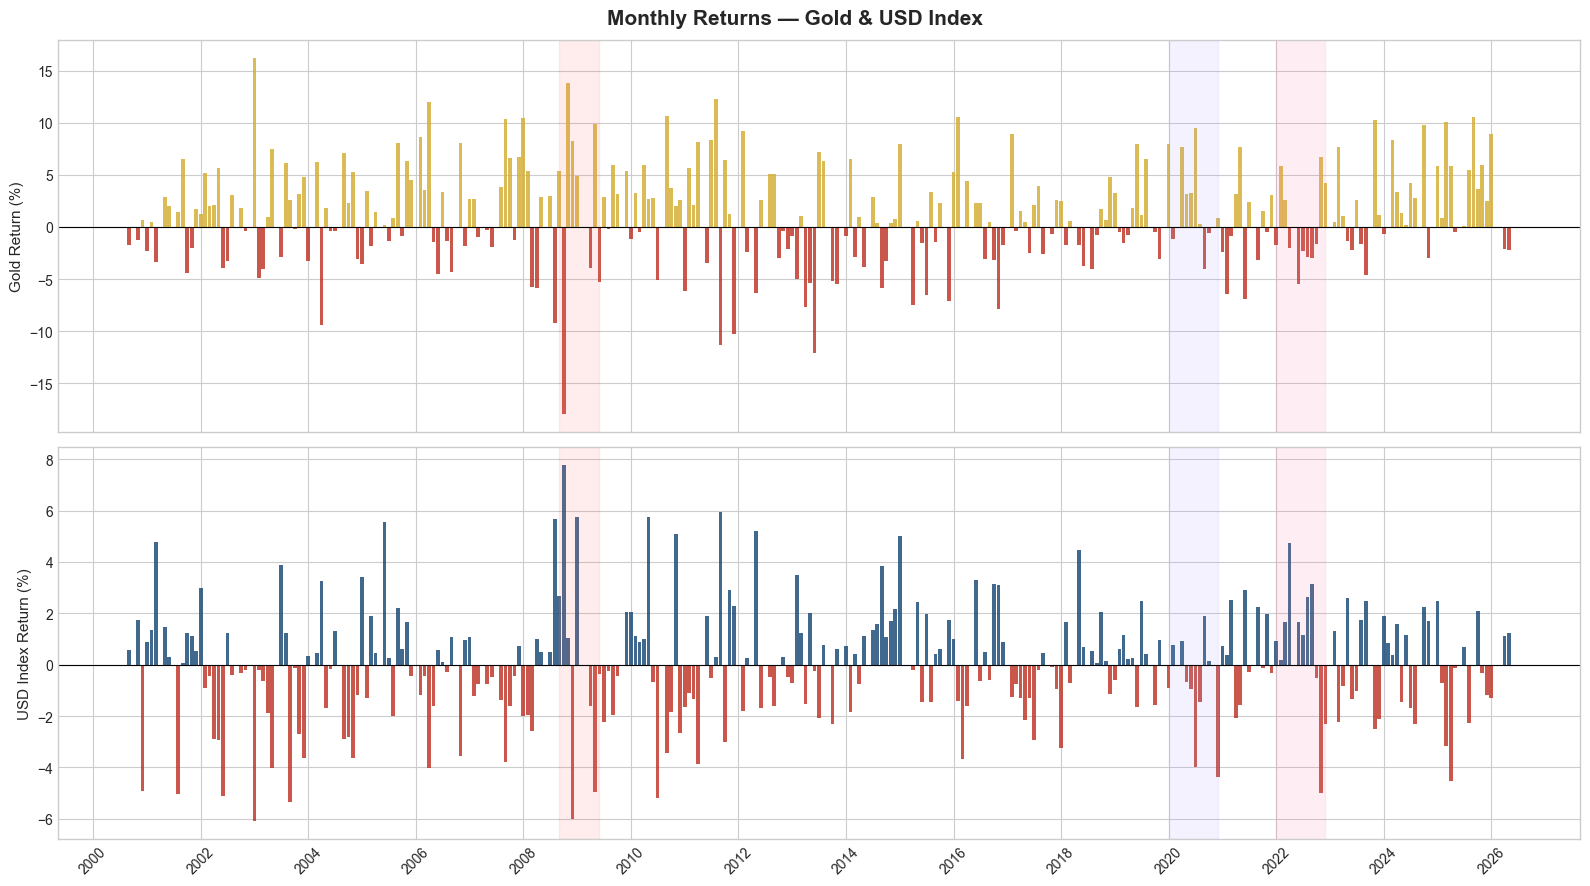

In [12]:
# ─── Monthly Returns ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Monthly Returns — Gold & USD Index', fontsize=15, fontweight='bold')

for ax, col, color, label in [(ax1, 'Gold_Return', GOLD, 'Gold'),
                               (ax2, 'USD_Return', BLUE, 'USD Index')]:
    returns = df[col].dropna()
    colors  = [color if r >= 0 else RED for r in returns]
    ax.bar(returns.index, returns, color=colors, width=25, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel(f'{label} Return (%)', fontsize=11)
    for start, end, lbl, col2 in crisis_periods:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color=col2)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ts_returns.png', dpi=150, bbox_inches='tight')
plt.show()

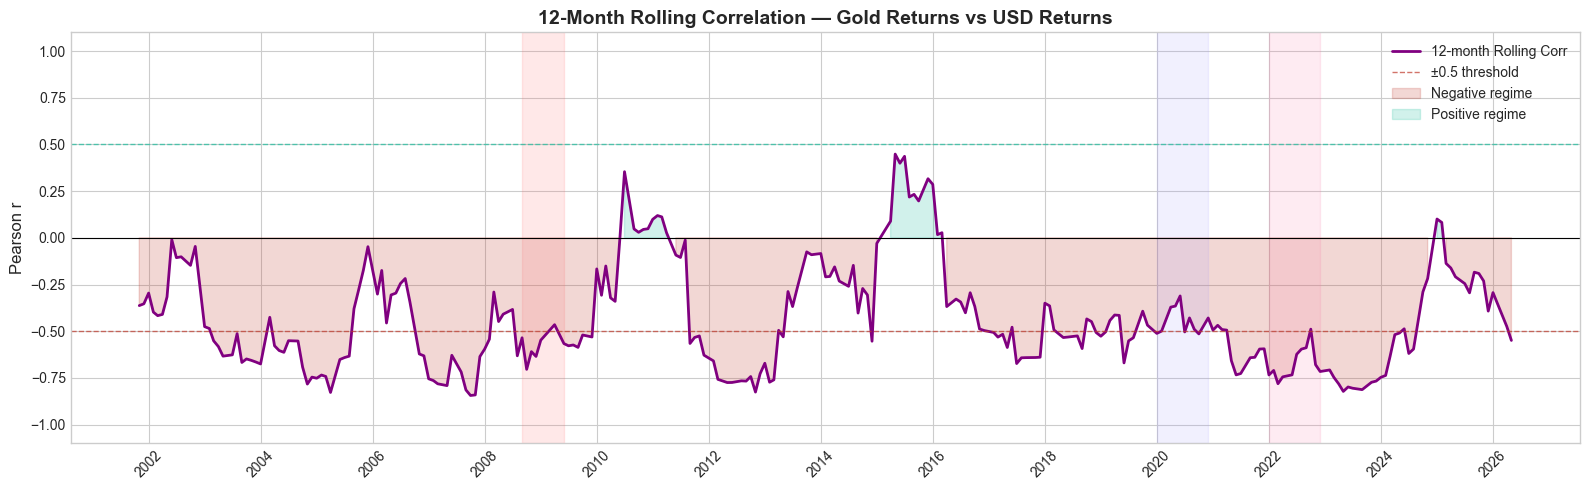

In [13]:
# ─── Rolling 12-month Correlation ─────────────────────────────────────────────
df['Roll_Corr_12m'] = df['Gold_Return'].rolling(12).corr(df['USD_Return'])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['Roll_Corr_12m'], color='purple', linewidth=2, label='12-month Rolling Corr')
ax.axhline(0,    color='black', linewidth=0.8, linestyle='-')
ax.axhline(-0.5, color=RED,   linewidth=1,   linestyle='--', alpha=0.7, label='±0.5 threshold')
ax.axhline( 0.5, color=GREEN, linewidth=1,   linestyle='--', alpha=0.7)
ax.fill_between(df.index, df['Roll_Corr_12m'], 0,
                where=df['Roll_Corr_12m'] < 0, alpha=0.2, color=RED,   label='Negative regime')
ax.fill_between(df.index, df['Roll_Corr_12m'], 0,
                where=df['Roll_Corr_12m'] >= 0, alpha=0.2, color=GREEN, label='Positive regime')
for start, end, lbl, col in crisis_periods:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=col)
ax.set_title('12-Month Rolling Correlation — Gold Returns vs USD Returns', fontsize=14, fontweight='bold')
ax.set_ylabel('Pearson r', fontsize=12)
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rolling_corr.png', dpi=150, bbox_inches='tight')
plt.show()

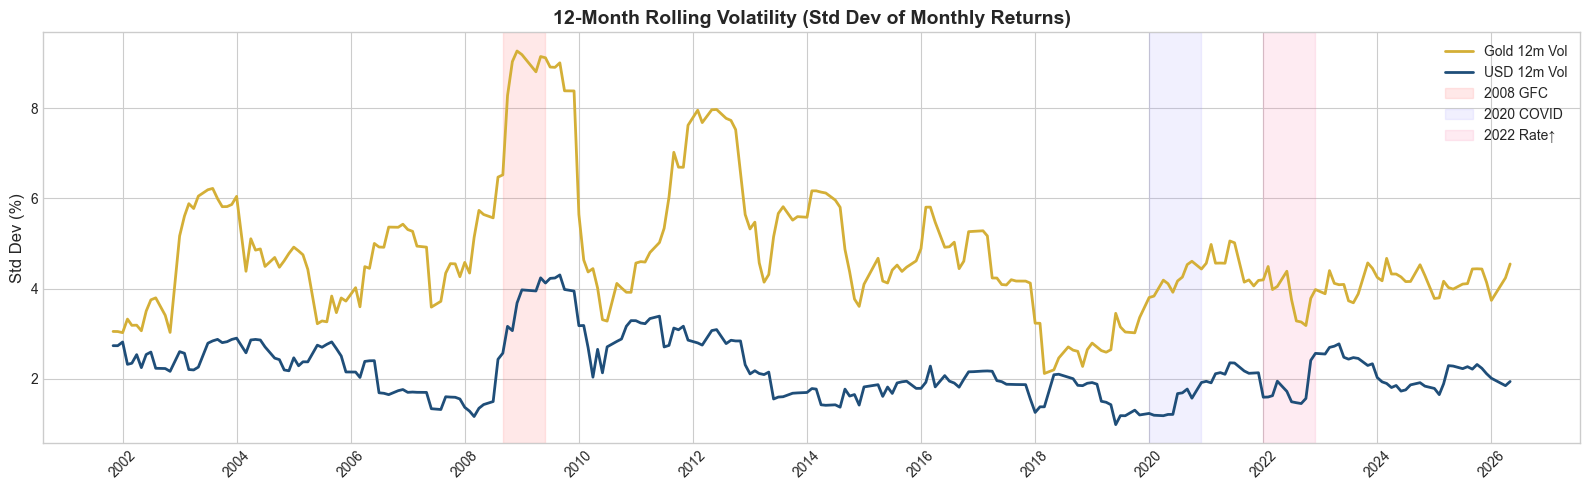

In [14]:
# ─── Rolling 12-month Volatility ──────────────────────────────────────────────
df['Gold_Vol'] = df['Gold_Return'].rolling(12).std()
df['USD_Vol']  = df['USD_Return'].rolling(12).std()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['Gold_Vol'], color=GOLD, linewidth=2, label='Gold 12m Vol')
ax.plot(df.index, df['USD_Vol'],  color=BLUE, linewidth=2, label='USD 12m Vol')
for start, end, lbl, col in crisis_periods:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=col, label=lbl)
ax.set_title('12-Month Rolling Volatility (Std Dev of Monthly Returns)', fontsize=14, fontweight='bold')
ax.set_ylabel('Std Dev (%)', fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

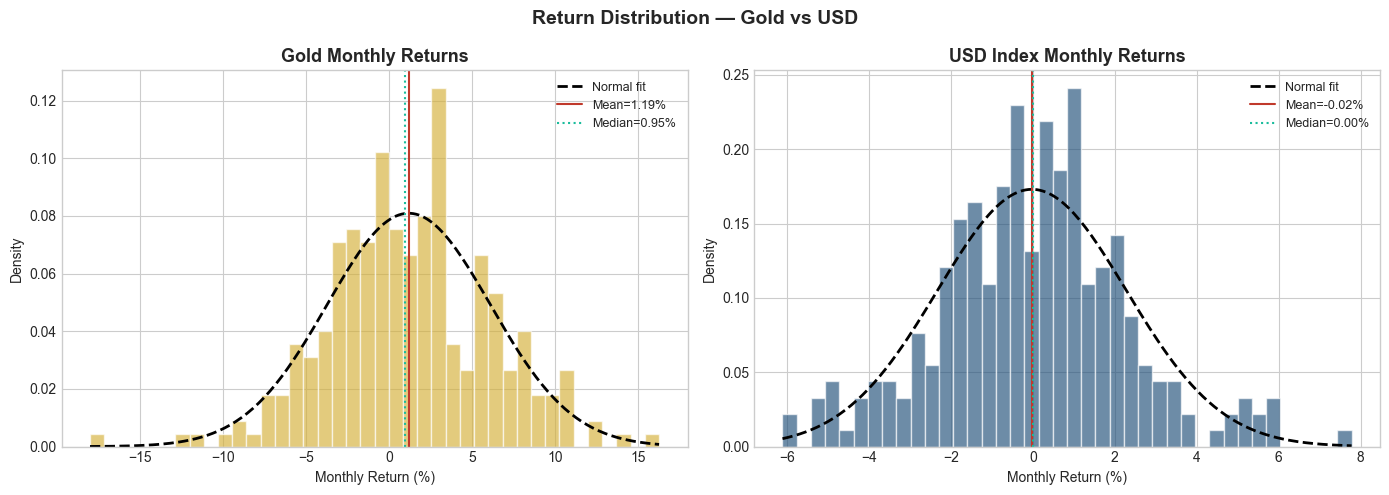

In [15]:
# ─── Distribution Plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Return Distribution — Gold vs USD', fontsize=14, fontweight='bold')

for ax, col, color, label in zip(axes,
    ['Gold_Return', 'USD_Return'], [GOLD, BLUE], ['Gold', 'USD Index']):
    data_s = df[col].dropna()
    ax.hist(data_s, bins=40, color=color, alpha=0.65, edgecolor='white', density=True)
    xr = np.linspace(data_s.min(), data_s.max(), 200)
    ax.plot(xr, stats.norm.pdf(xr, data_s.mean(), data_s.std()),
            color='black', linewidth=2, linestyle='--', label='Normal fit')
    ax.axvline(data_s.mean(),   color=RED,   linewidth=1.5, linestyle='-', label=f'Mean={data_s.mean():.2f}%')
    ax.axvline(data_s.median(), color=GREEN, linewidth=1.5, linestyle=':', label=f'Median={data_s.median():.2f}%')
    ax.set_title(f'{label} Monthly Returns', fontsize=13, fontweight='bold')
    ax.set_xlabel('Monthly Return (%)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='5'></a>
## 5. Abnormal Periods — Zoomed Graphs

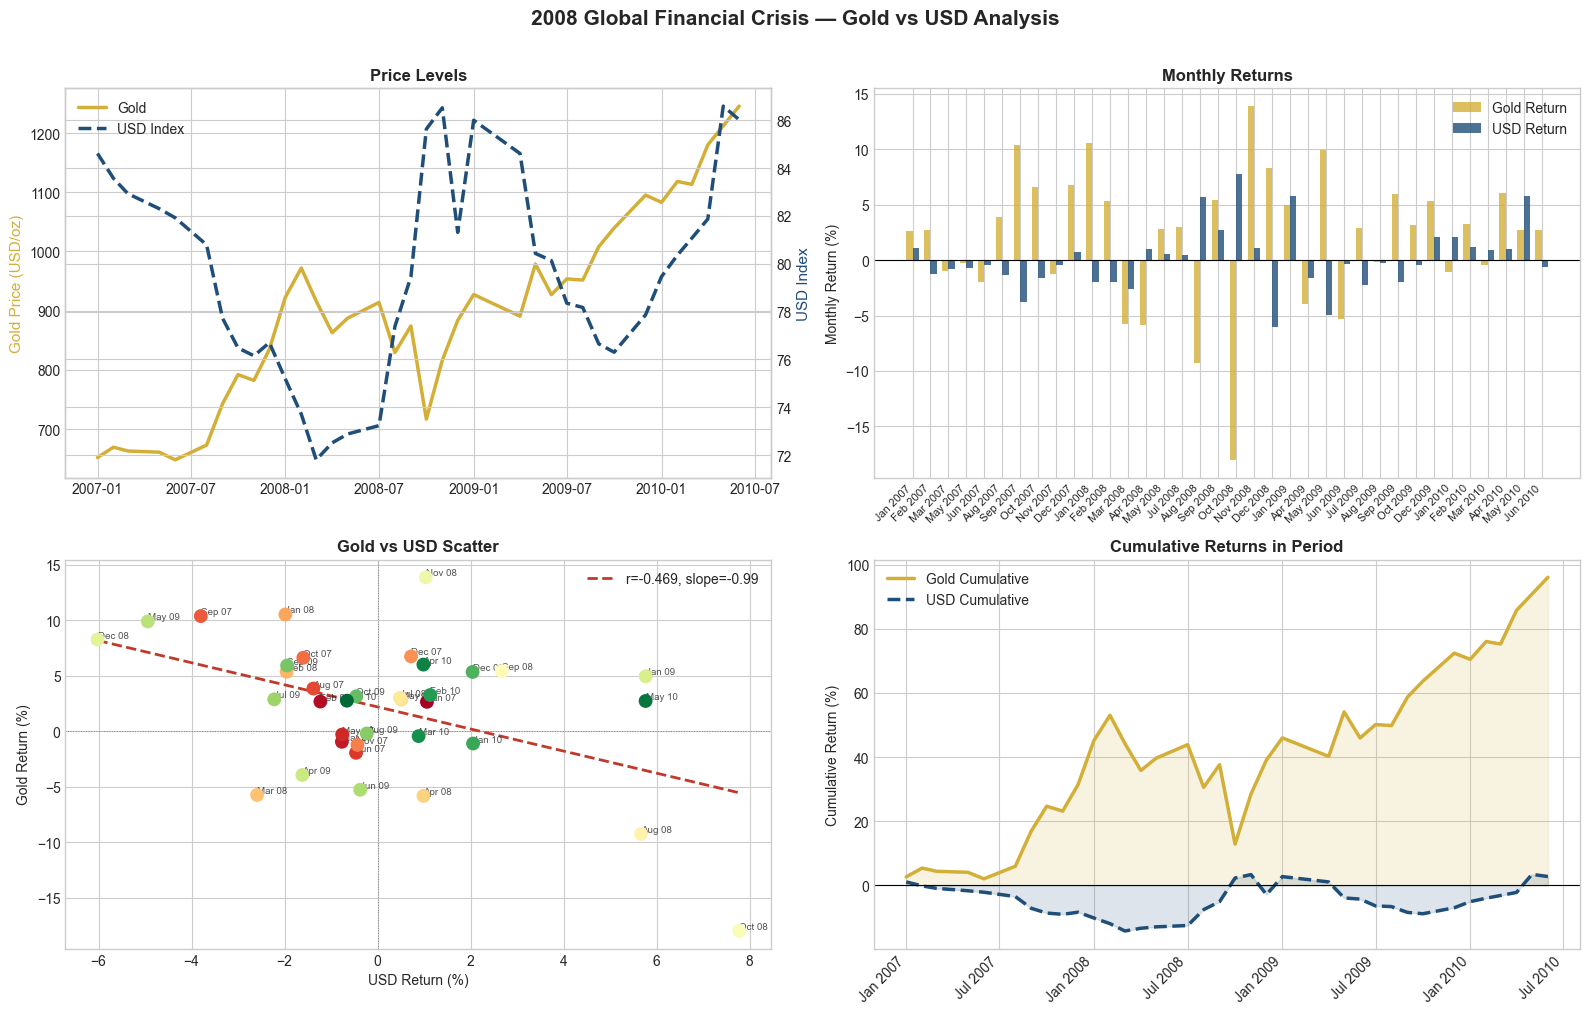

Figure saved → crisis_2008.png


In [16]:
def plot_crisis_zoom(start, end, title, fig_name):
    """Zoomed twin-axis plot for a crisis window with outlier months flagged."""
    mask = (df.index >= pd.Timestamp(start)) & (df.index <= pd.Timestamp(end))
    sub  = df.loc[mask].copy()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.01)

    # ── Price levels ──────────────────────────────────────────────────────────
    ax1, ax2 = axes[0, 0], axes[0, 0].twinx()
    ln1 = ax1.plot(sub.index, sub['Gold_Price'], color=GOLD, linewidth=2.5, label='Gold')
    ln2 = ax2.plot(sub.index, sub['USD_Index'],  color=BLUE, linewidth=2.5, linestyle='--', label='USD Index')
    ax1.set_ylabel('Gold Price (USD/oz)', color=GOLD, fontsize=11)
    ax2.set_ylabel('USD Index', color=BLUE, fontsize=11)
    axes[0, 0].set_title('Price Levels', fontweight='bold')
    lns = ln1 + ln2
    axes[0, 0].legend(lns, [l.get_label() for l in lns], fontsize=10)

    # ── Monthly returns ───────────────────────────────────────────────────────
    ax = axes[0, 1]
    x = np.arange(len(sub))
    width = 0.35
    ax.bar(x - width/2, sub['Gold_Return'], width, color=GOLD, alpha=0.8, label='Gold Return')
    ax.bar(x + width/2, sub['USD_Return'],  width, color=BLUE, alpha=0.8, label='USD Return')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index.strftime('%b %Y'), rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Monthly Return (%)')
    ax.set_title('Monthly Returns', fontweight='bold')
    ax.legend(fontsize=10)

    # ── Scatter: Gold vs USD returns ──────────────────────────────────────────
    ax = axes[1, 0]
    sc = ax.scatter(sub['USD_Return'], sub['Gold_Return'],
                    c=range(len(sub)), cmap='RdYlGn', s=80, zorder=5)
    for i, row in sub.iterrows():
        ax.annotate(i.strftime('%b %y'), (row['USD_Return'], row['Gold_Return']),
                    fontsize=7, ha='left', va='bottom', alpha=0.8)
    m, b, r, p, se = stats.linregress(sub['USD_Return'].dropna(), sub['Gold_Return'].dropna())
    xfit = np.linspace(sub['USD_Return'].min(), sub['USD_Return'].max(), 100)
    ax.plot(xfit, m * xfit + b, color=RED, linewidth=2, linestyle='--',
            label=f'r={r:.3f}, slope={m:.2f}')
    ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
    ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
    ax.set_xlabel('USD Return (%)')
    ax.set_ylabel('Gold Return (%)')
    ax.set_title('Gold vs USD Scatter', fontweight='bold')
    ax.legend(fontsize=10)

    # ── Cumulative returns ─────────────────────────────────────────────────────
    ax = axes[1, 1]
    cum_gold = (1 + sub['Gold_Return'] / 100).cumprod() - 1
    cum_usd  = (1 + sub['USD_Return']  / 100).cumprod() - 1
    ax.plot(sub.index, cum_gold * 100, color=GOLD, linewidth=2.5, label='Gold Cumulative')
    ax.plot(sub.index, cum_usd  * 100, color=BLUE, linewidth=2.5, linestyle='--', label='USD Cumulative')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.fill_between(sub.index, cum_gold * 100, 0, alpha=0.15, color=GOLD)
    ax.fill_between(sub.index, cum_usd  * 100, 0, alpha=0.15, color=BLUE)
    ax.set_ylabel('Cumulative Return (%)')
    ax.set_title('Cumulative Returns in Period', fontweight='bold')
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(fig_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved → {fig_name}')

# ── 2008 Global Financial Crisis ──────────────────────────────────────────────
plot_crisis_zoom('2007-01-01', '2010-06-01',
                 '2008 Global Financial Crisis — Gold vs USD Analysis',
                 'crisis_2008.png')

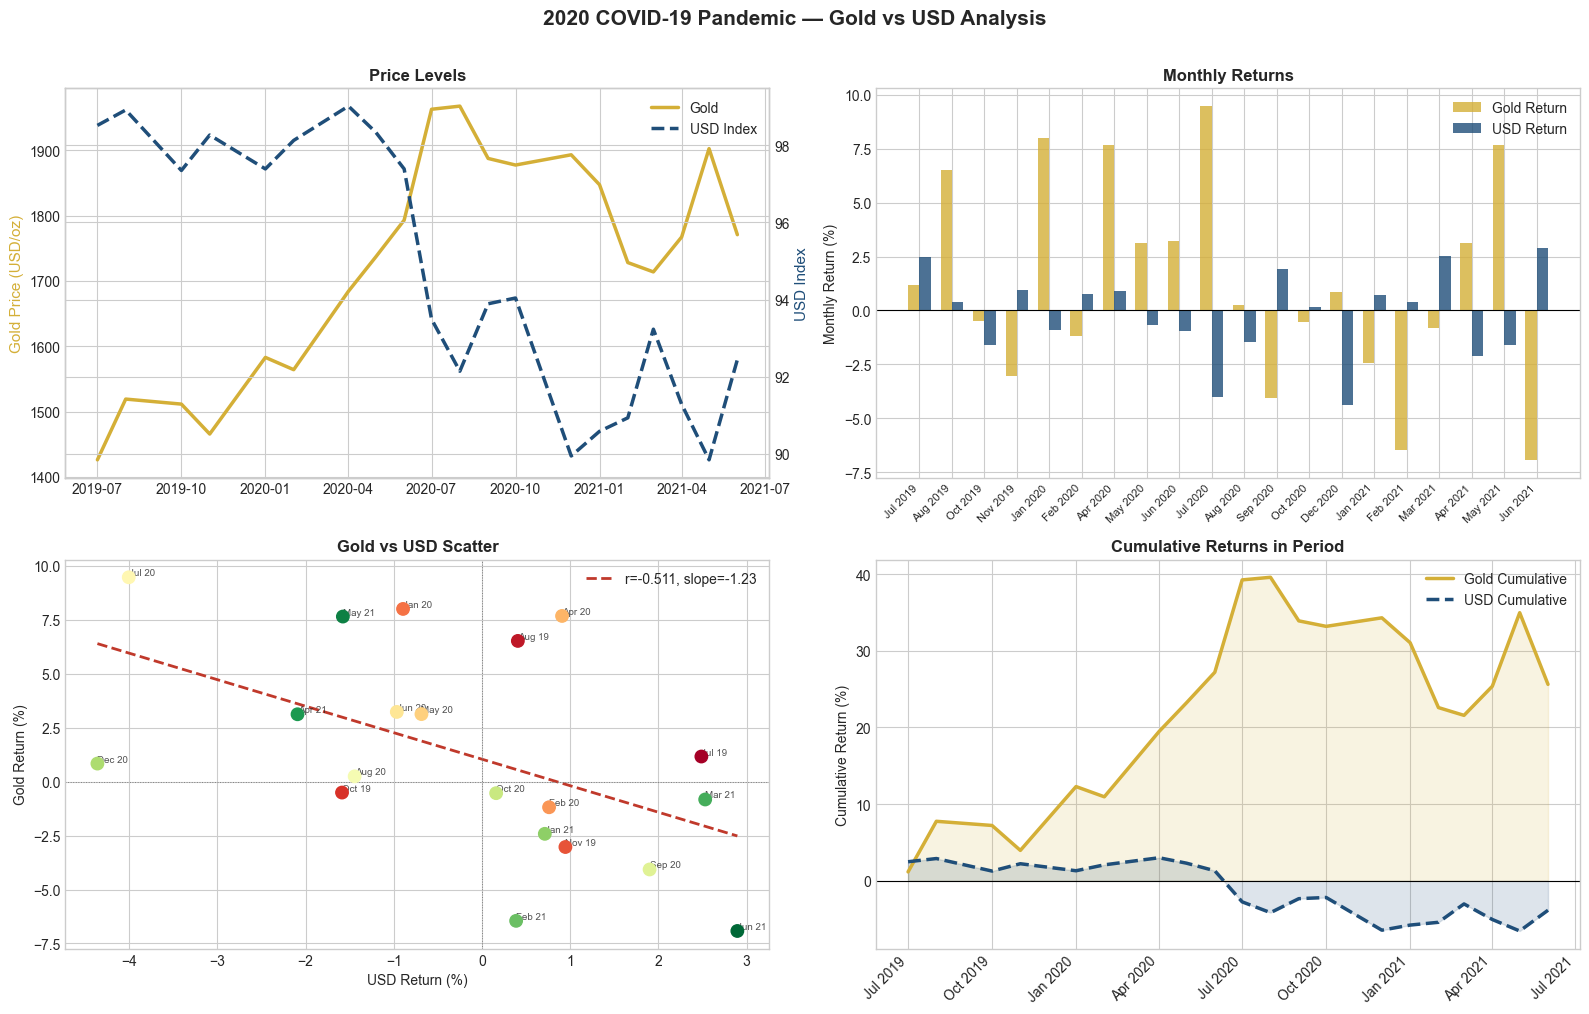

Figure saved → crisis_2020.png


In [17]:
# ── 2020 COVID-19 ─────────────────────────────────────────────────────────────
plot_crisis_zoom('2019-07-01', '2021-06-01',
                 '2020 COVID-19 Pandemic — Gold vs USD Analysis',
                 'crisis_2020.png')

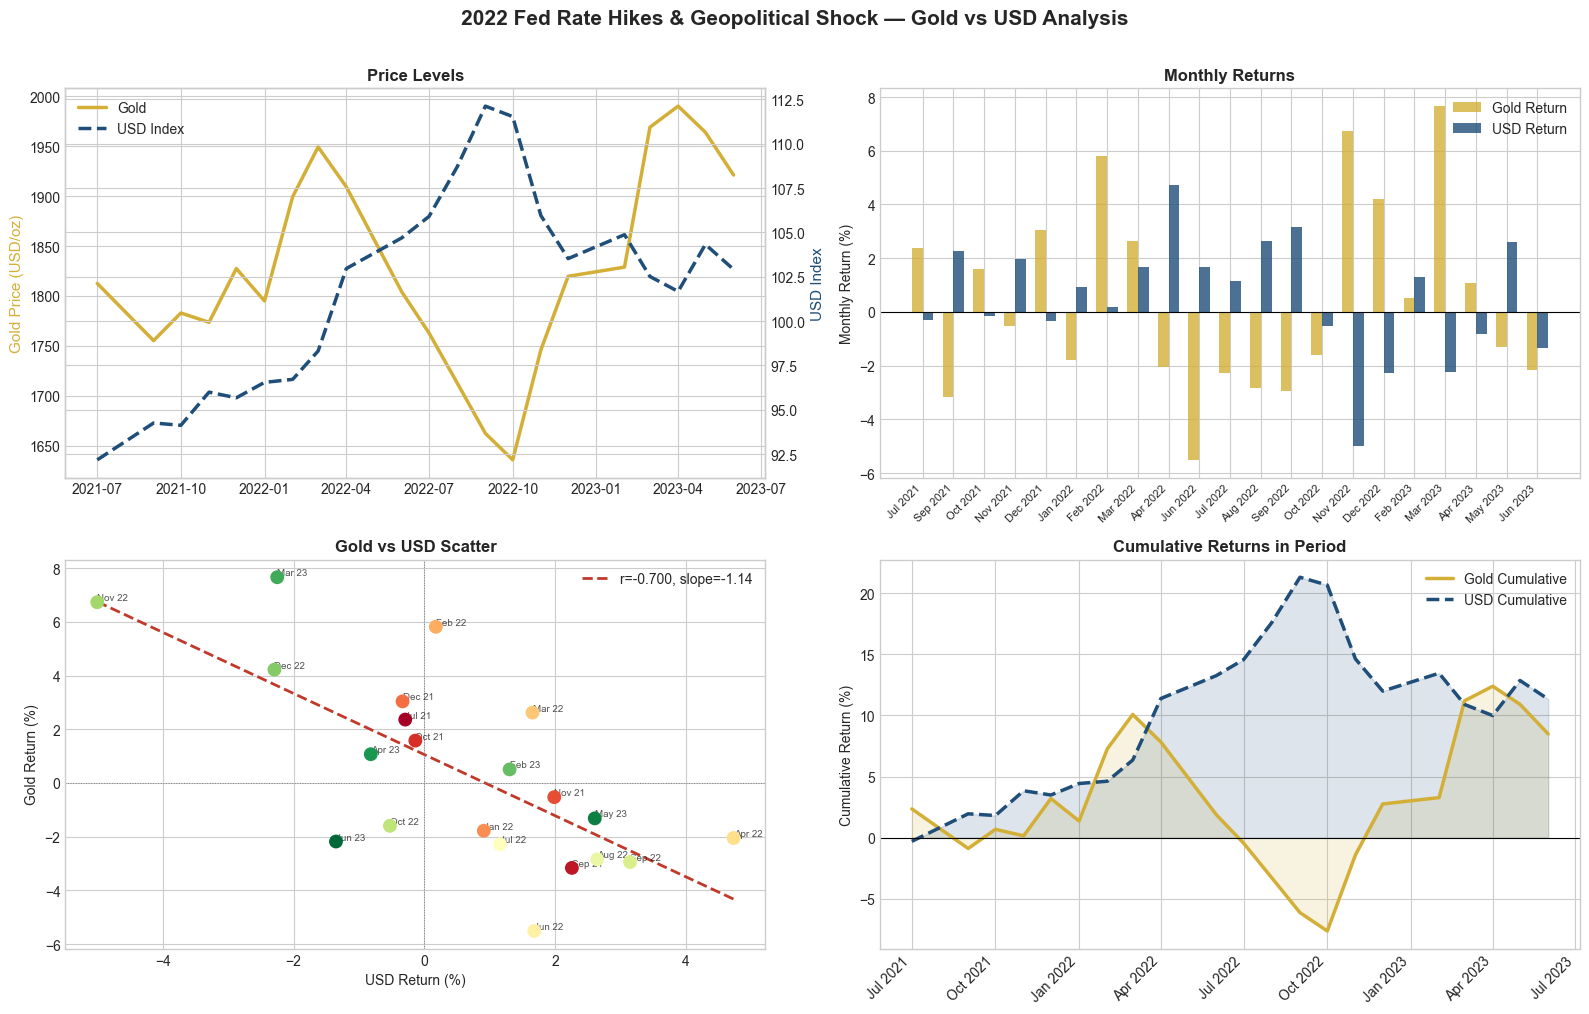

Figure saved → crisis_2022.png


In [18]:
# ── 2022 Fed Rate Hikes / Ukraine War ─────────────────────────────────────────
plot_crisis_zoom('2021-07-01', '2023-06-01',
                 '2022 Fed Rate Hikes & Geopolitical Shock — Gold vs USD Analysis',
                 'crisis_2022.png')

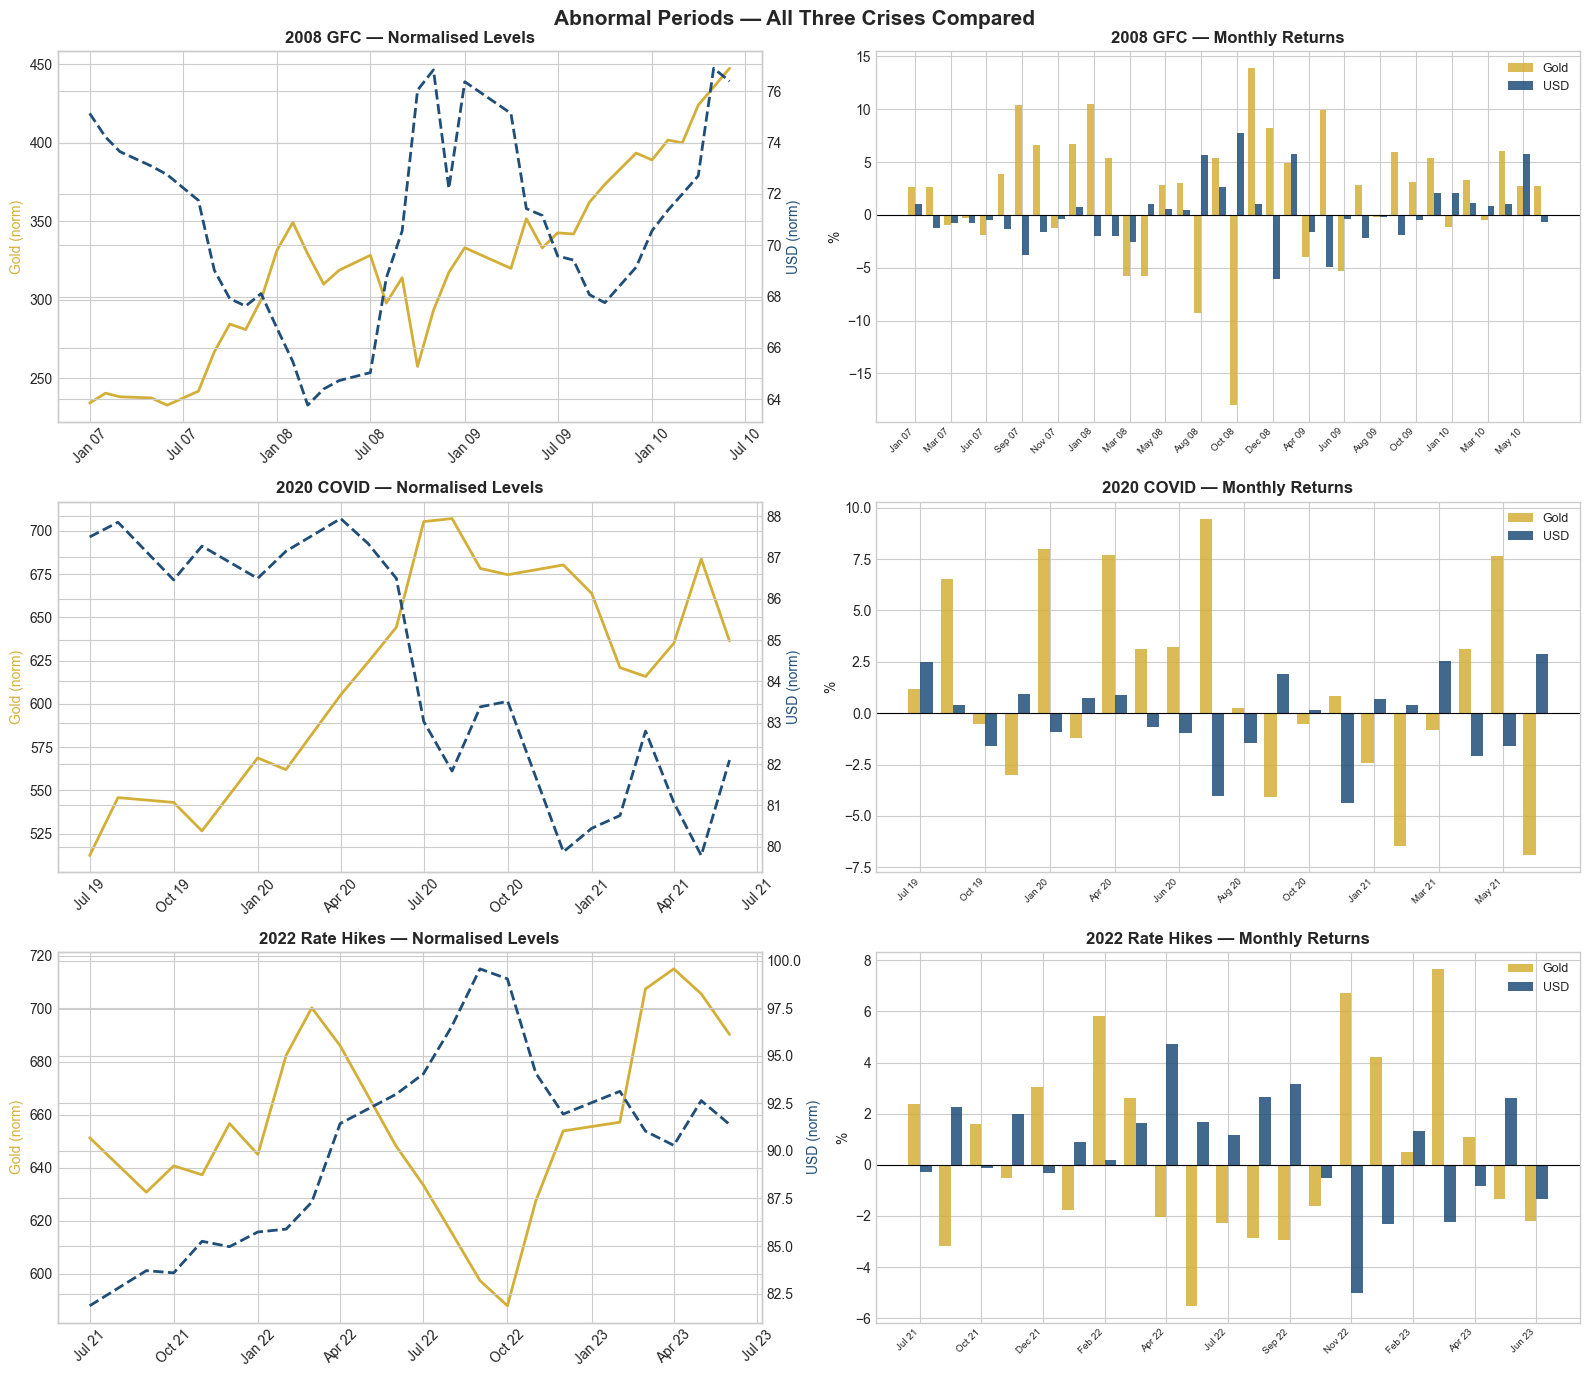

In [19]:
# ─── All Three Crises Side-by-Side ────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Abnormal Periods — All Three Crises Compared', fontsize=15, fontweight='bold')

windows = [
    ('2007-01-01', '2010-06-01', '2008 GFC'),
    ('2019-07-01', '2021-06-01', '2020 COVID'),
    ('2021-07-01', '2023-06-01', '2022 Rate Hikes'),
]

for row, (start, end, label) in enumerate(windows):
    mask = (df.index >= pd.Timestamp(start)) & (df.index <= pd.Timestamp(end))
    sub  = df.loc[mask]

    ax = axes[row, 0]
    ax2 = ax.twinx()
    ax.plot(sub.index, sub['Gold_Norm'], color=GOLD, linewidth=2, label='Gold')
    ax2.plot(sub.index, sub['USD_Norm'], color=BLUE, linewidth=2, linestyle='--', label='USD')
    ax.set_ylabel('Gold (norm)', color=GOLD)
    ax2.set_ylabel('USD (norm)', color=BLUE)
    ax.set_title(f'{label} — Normalised Levels', fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

    ax = axes[row, 1]
    x = np.arange(len(sub))
    w = 0.38
    ax.bar(x - w/2, sub['Gold_Return'], w, color=GOLD, alpha=0.85, label='Gold')
    ax.bar(x + w/2, sub['USD_Return'],  w, color=BLUE, alpha=0.85, label='USD')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x[::2])
    ax.set_xticklabels(sub.index[::2].strftime('%b %y'), rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{label} — Monthly Returns', fontweight='bold')
    ax.set_ylabel('%')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('all_crises.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='6'></a>
## 6. Correlation Analysis

In [20]:
# ─── Full-Period Correlations ──────────────────────────────────────────────────
ret = df[['Gold_Return', 'USD_Return']].dropna()

pear_r, pear_p = pearsonr(ret['Gold_Return'], ret['USD_Return'])
spear_r, spear_p = spearmanr(ret['Gold_Return'], ret['USD_Return'])
kend_r, kend_p  = kendalltau(ret['Gold_Return'], ret['USD_Return'])

print('=' * 60)
print('  FULL PERIOD CORRELATION (Monthly Returns)')
print('=' * 60)
print(f'  Pearson  r = {pear_r:.4f}   p = {pear_p:.6f}  {"✅ Significant" if pear_p < 0.05 else "❌ Not Significant"}')
print(f'  Spearman r = {spear_r:.4f}   p = {spear_p:.6f}  {"✅ Significant" if spear_p < 0.05 else "❌ Not Significant"}')
print(f'  Kendall  τ = {kend_r:.4f}   p = {kend_p:.6f}  {"✅ Significant" if kend_p < 0.05 else "❌ Not Significant"}')

print('\n  Correlation Matrix (Returns):')
print(ret.corr().round(4).to_string())

print('\n  Correlation Matrix (Log Returns):')
print(df[['Gold_LogRet', 'USD_LogRet']].dropna().corr().round(4).to_string())

  FULL PERIOD CORRELATION (Monthly Returns)
  Pearson  r = -0.4475   p = 0.000000  ✅ Significant
  Spearman r = -0.4281   p = 0.000000  ✅ Significant
  Kendall  τ = -0.3043   p = 0.000000  ✅ Significant

  Correlation Matrix (Returns):
Ticker       Gold_Return  USD_Return
Ticker                              
Gold_Return       1.0000     -0.4475
USD_Return       -0.4475      1.0000

  Correlation Matrix (Log Returns):
Ticker       Gold_LogRet  USD_LogRet
Ticker                              
Gold_LogRet       1.0000     -0.4490
USD_LogRet       -0.4490      1.0000


In [21]:
# ─── Sub-period correlations: Abnormal vs Normal ───────────────────────────────
print('=' * 60)
print('  SUB-PERIOD CORRELATION ANALYSIS')
print('=' * 60)
sub_periods = {
    'Pre-GFC   (2001–2007)': ('2001-01-01', '2007-08-01'),
    '2008 GFC  (Sep08–Jun09)': ('2008-09-01', '2009-06-01'),
    'Recovery  (2009–2019)': ('2009-07-01', '2019-12-01'),
    '2020 COVID (2020)': ('2020-01-01', '2020-12-01'),
    '2022 Hikes (2022)': ('2022-01-01', '2022-12-01'),
    'Recent    (2023–2025)': ('2023-01-01', '2025-12-01'),
}
rows = []
for name, (s, e) in sub_periods.items():
    sub = df.loc[(df.index >= pd.Timestamp(s)) & (df.index <= pd.Timestamp(e)),
                 ['Gold_Return', 'USD_Return']].dropna()
    if len(sub) > 5:
        r, p = pearsonr(sub['Gold_Return'], sub['USD_Return'])
        rows.append({'Period': name, 'N': len(sub), 'Pearson_r': round(r, 4), 'p_value': round(p, 5)})

corr_table = pd.DataFrame(rows)
print(corr_table.to_string(index=False))

  SUB-PERIOD CORRELATION ANALYSIS
                 Period   N  Pearson_r  p_value
  Pre-GFC   (2001–2007)  68    -0.4822   0.0000
2008 GFC  (Sep08–Jun09)   8    -0.5172   0.1893
  Recovery  (2009–2019) 107    -0.3368   0.0004
      2020 COVID (2020)  10    -0.4045   0.2463
      2022 Hikes (2022)  11    -0.7113   0.0141
  Recent    (2023–2025)  31    -0.3931   0.0287


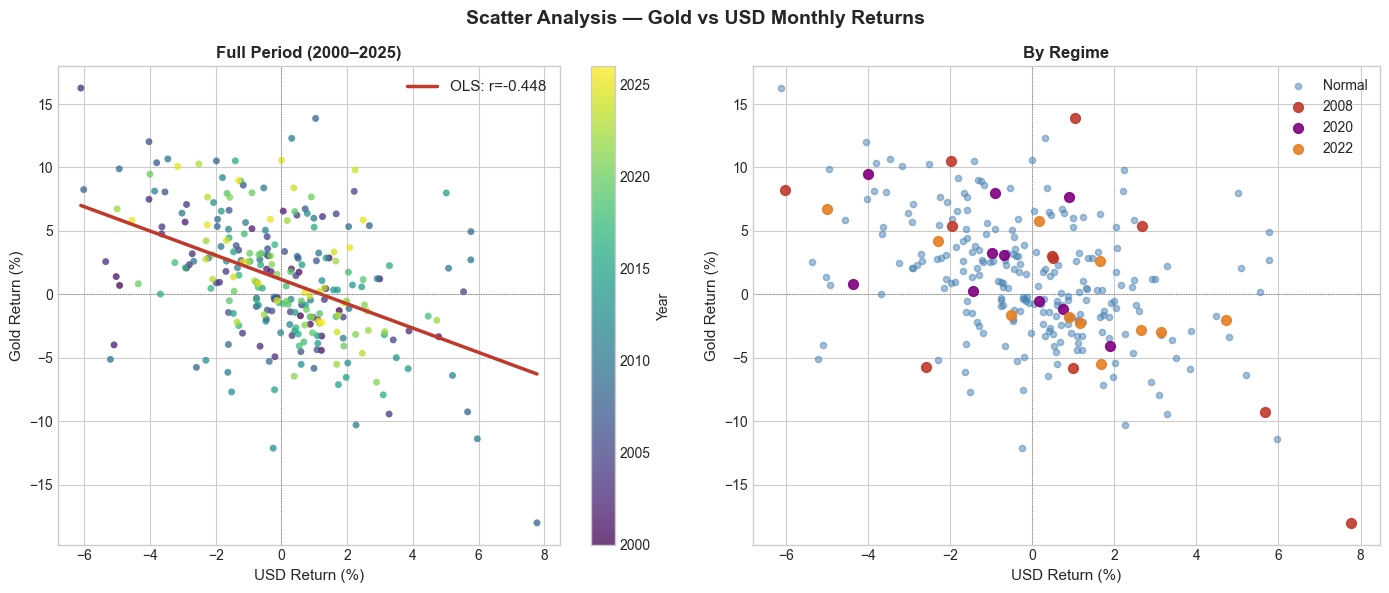

In [22]:
# ─── Scatter Plot — Full Period ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Scatter Analysis — Gold vs USD Monthly Returns', fontsize=14, fontweight='bold')

# Full period
ax = axes[0]
years = df['Year'].values
sc = ax.scatter(df['USD_Return'], df['Gold_Return'], c=years, cmap='viridis',
                s=25, alpha=0.75, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Year')
m, b, r, p, _ = stats.linregress(df['USD_Return'].dropna(), df['Gold_Return'].dropna())
xfit = np.linspace(df['USD_Return'].min(), df['USD_Return'].max(), 200)
ax.plot(xfit, m * xfit + b, color=RED, linewidth=2.5, label=f'OLS: r={r:.3f}')
ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
ax.set_xlabel('USD Return (%)', fontsize=11)
ax.set_ylabel('Gold Return (%)', fontsize=11)
ax.set_title('Full Period (2000–2025)', fontweight='bold')
ax.legend(fontsize=11)

# By regime
ax = axes[1]
regimes = {
    'Normal': df[~df['Year'].isin([2008, 2020, 2022])],
    '2008':   df[df['Year'] == 2008],
    '2020':   df[df['Year'] == 2020],
    '2022':   df[df['Year'] == 2022],
}
regime_colors = {'Normal': 'steelblue', '2008': RED, '2020': 'purple', '2022': ORANGE}
for name, sub in regimes.items():
    sub = sub.dropna(subset=['USD_Return', 'Gold_Return'])
    ax.scatter(sub['USD_Return'], sub['Gold_Return'],
               color=regime_colors[name], label=name,
               s=50 if name != 'Normal' else 20,
               alpha=0.9 if name != 'Normal' else 0.5,
               zorder=5 if name != 'Normal' else 3)
ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
ax.set_xlabel('USD Return (%)', fontsize=11)
ax.set_ylabel('Gold Return (%)', fontsize=11)
ax.set_title('By Regime', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('scatter_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

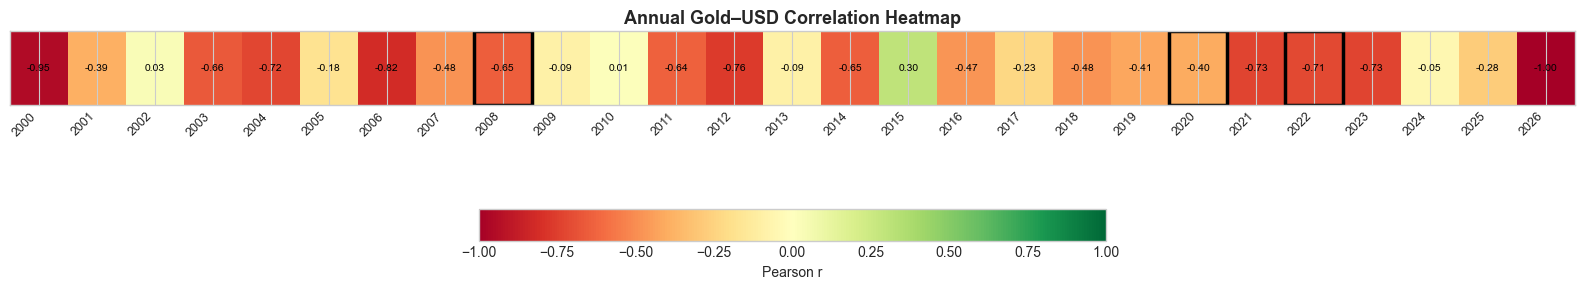

In [23]:
# ─── Annual Correlation Heatmap ───────────────────────────────────────────────
ann_corr = annual['Corr'].values.reshape(-1, 1)
ann_years = annual.index.tolist()

fig, ax = plt.subplots(figsize=(16, 3))
im = ax.imshow(ann_corr.T, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.5, label='Pearson r')
ax.set_xticks(range(len(ann_years)))
ax.set_xticklabels(ann_years, rotation=45, ha='right', fontsize=9)
ax.set_yticks([])
ax.set_title('Annual Gold–USD Correlation Heatmap', fontsize=13, fontweight='bold')
for i, yr in enumerate(ann_years):
    ax.text(i, 0, f'{annual.loc[yr, "Corr"]:.2f}', ha='center', va='center',
            fontsize=7.5, color='black')
    if yr in abnormal_years:
        ax.add_patch(mpatches.Rectangle((i - 0.5, -0.5), 1, 1,
                     linewidth=2.5, edgecolor='black', facecolor='none'))
plt.tight_layout()
plt.savefig('annual_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='7'></a>
## 7. Regression Analysis

In [24]:
# ─── Simple OLS via scipy ─────────────────────────────────────────────────────
clean = df[['Gold_Return', 'USD_Return']].dropna()
slope, intercept, r_value, p_value, std_err = stats.linregress(
    clean['USD_Return'], clean['Gold_Return'])

print('=' * 60)
print('  SIMPLE OLS REGRESSION')
print('  Gold_Return = α + β × USD_Return + ε')
print('=' * 60)
print(f'  Intercept (α)  : {intercept:.4f}')
print(f'  Slope (β)      : {slope:.4f}  ← per 1% USD move, Gold moves {slope:.2f}%')
print(f'  R²             : {r_value**2:.4f}  ({r_value**2*100:.1f}% variance explained)')
print(f'  p-value        : {p_value:.6f}  {"✅ Significant" if p_value < 0.05 else "❌ Not significant"}')
print(f'  Std Error      : {std_err:.4f}')

print('\n--- Residuals ---')
fitted   = intercept + slope * clean['USD_Return']
residuals = clean['Gold_Return'] - fitted
print(f'  Residual Mean : {residuals.mean():.4f}')
print(f'  Residual Std  : {residuals.std():.4f}')
_, jb_p = stats.normaltest(residuals)
print(f'  Jarque-Bera (normality) p = {jb_p:.4f}  {"✅ Normal" if jb_p > 0.05 else "❌ Non-normal"}')

  SIMPLE OLS REGRESSION
  Gold_Return = α + β × USD_Return + ε
  Intercept (α)  : 1.1648
  Slope (β)      : -0.9564  ← per 1% USD move, Gold moves -0.96%
  R²             : 0.2003  (20.0% variance explained)
  p-value        : 0.000000  ✅ Significant
  Std Error      : 0.1183

--- Residuals ---
  Residual Mean : -0.0000
  Residual Std  : 4.4082
  Jarque-Bera (normality) p = 0.3676  ✅ Normal


In [25]:
# ─── Regression with statsmodels (full OLS table) ────────────────────────────
if STATSMODELS:
    import statsmodels.api as sm
    X = add_constant(clean['USD_Return'])
    model = OLS(clean['Gold_Return'], X).fit()
    print(model.summary())
    print(f'\n  Durbin-Watson statistic: {durbin_watson(model.resid):.4f}')
    print('  (Values near 2.0 indicate no autocorrelation)')
else:
    print('statsmodels not available — install it for a full OLS summary table.')

                            OLS Regression Results                            
Dep. Variable:            Gold_Return   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     65.36
Date:                Thu, 21 May 2026   Prob (F-statistic):           2.35e-14
Time:                        16:19:59   Log-Likelihood:                -762.83
No. Observations:                 263   AIC:                             1530.
Df Residuals:                     261   BIC:                             1537.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1648      0.272      4.277      0.0

  REGRESSION β COEFFICIENT BY PERIOD
                 Period   N    Beta     R2      p
  Pre-GFC   (2001–2007)  68 -0.9040 0.2326 0.0000
2008 GFC  (Sep08–Jun09)   8 -1.1099 0.2675 0.1893
  Recovery  (2009–2019) 107 -0.7682 0.1135 0.0004
      2020 COVID (2020)  10 -0.8934 0.1636 0.2463
      2022 Hikes (2022)  11 -1.0848 0.5059 0.0141
  Recent    (2023–2025)  31 -0.8519 0.1545 0.0287


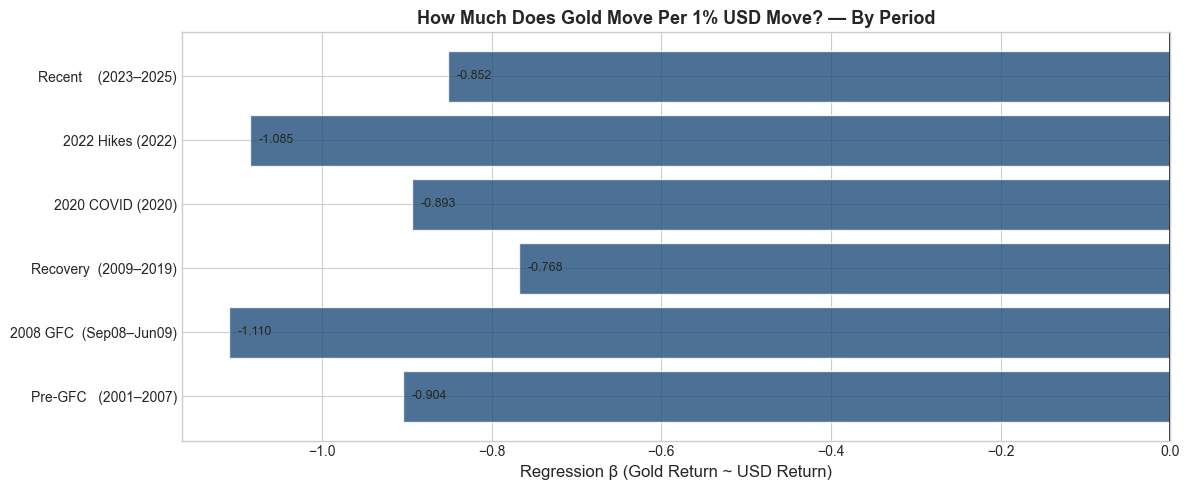

In [26]:
# ─── Regression by Sub-period ─────────────────────────────────────────────────
print('=' * 65)
print('  REGRESSION β COEFFICIENT BY PERIOD')
print('=' * 65)

period_betas = []
for name, (s, e) in sub_periods.items():
    sub = df.loc[(df.index >= pd.Timestamp(s)) & (df.index <= pd.Timestamp(e)),
                 ['Gold_Return', 'USD_Return']].dropna()
    if len(sub) > 5:
        sl, ic, rv, pv, se2 = stats.linregress(sub['USD_Return'], sub['Gold_Return'])
        period_betas.append({'Period': name, 'N': len(sub),
                              'Beta': round(sl, 4), 'R2': round(rv**2, 4), 'p': round(pv, 4)})

beta_df = pd.DataFrame(period_betas)
print(beta_df.to_string(index=False))

# Visual
fig, ax = plt.subplots(figsize=(12, 5))
colors_b = [RED if b > 0 else BLUE for b in beta_df['Beta']]
bars = ax.barh(beta_df['Period'], beta_df['Beta'], color=colors_b, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Regression β (Gold Return ~ USD Return)', fontsize=12)
ax.set_title('How Much Does Gold Move Per 1% USD Move? — By Period', fontsize=13, fontweight='bold')
for bar, val in zip(bars, beta_df['Beta']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig('regression_betas.png', dpi=150, bbox_inches='tight')
plt.show()

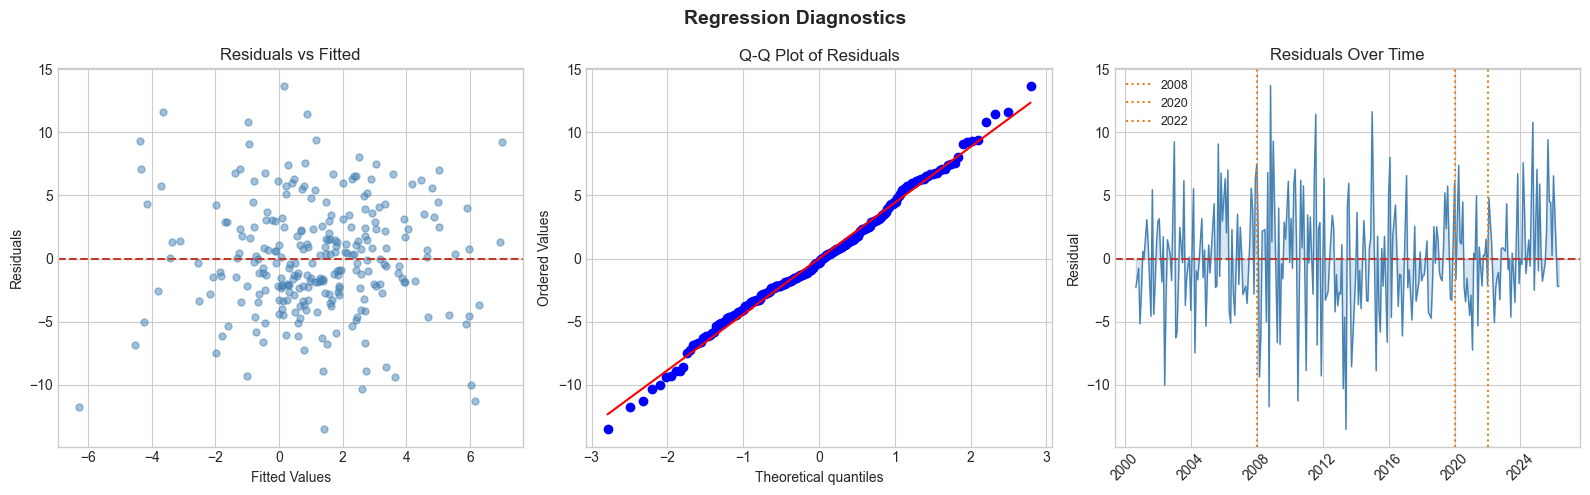

In [27]:
# ─── Residual Diagnostic Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Regression Diagnostics', fontsize=14, fontweight='bold')

# Fitted vs Residuals
axes[0].scatter(fitted, residuals, alpha=0.5, color='steelblue', s=25)
axes[0].axhline(0, color=RED, linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# QQ Plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# Residuals over time
axes[2].plot(clean.index, residuals.values, color='steelblue', linewidth=1)
axes[2].axhline(0, color=RED, linewidth=1.5, linestyle='--')
axes[2].fill_between(clean.index, residuals.values, 0, alpha=0.2, color='steelblue')
for yr in [2008, 2020, 2022]:
    axes[2].axvline(pd.Timestamp(f'{yr}-01-01'), color=ORANGE, linewidth=1.5, linestyle=':', label=str(yr))
axes[2].set_title('Residuals Over Time')
axes[2].set_ylabel('Residual')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator(4))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('regression_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='8'></a>
## 8. Lag Analysis & Cross-Correlation

In [28]:
# ─── Manual Lag Correlation ───────────────────────────────────────────────────
lags = range(-12, 13)   # -12 months to +12 months
lag_results = []

for lag in lags:
    if lag < 0:
        # USD leads Gold by |lag| months
        x = df['USD_Return'].iloc[:lag].values
        y = df['Gold_Return'].iloc[-lag:].values
    elif lag > 0:
        # Gold leads USD by lag months
        x = df['USD_Return'].iloc[lag:].values
        y = df['Gold_Return'].iloc[:-lag].values
    else:
        x = df['USD_Return'].dropna().values
        y = df['Gold_Return'].dropna().values

    min_len = min(len(x), len(y))
    x, y = x[:min_len], y[:min_len]
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() > 10:
        r, p = pearsonr(x[mask], y[mask])
        lag_results.append({'Lag': lag, 'Corr': r, 'p_value': p, 'Significant': p < 0.05})

lag_df = pd.DataFrame(lag_results)
print('Cross-Lag Correlations (negative lag = USD leads Gold):')
print(lag_df.to_string(index=False))

Cross-Lag Correlations (negative lag = USD leads Gold):
 Lag    Corr  p_value  Significant
 -12  0.0378   0.5510        False
 -11  0.0195   0.7579        False
 -10  0.0312   0.6212        False
  -9 -0.0073   0.9082        False
  -8 -0.0385   0.5408        False
  -7  0.0441   0.4822        False
  -6  0.0215   0.7320        False
  -5 -0.0027   0.9656        False
  -4  0.0103   0.8691        False
  -3 -0.0133   0.8306        False
  -2  0.0503   0.4180        False
  -1  0.0143   0.8180        False
   0 -0.4475   0.0000         True
   1 -0.0293   0.6366        False
   2  0.0508   0.4138        False
   3 -0.1961   0.0015         True
   4 -0.0208   0.7387        False
   5  0.0083   0.8939        False
   6  0.0244   0.6969        False
   7  0.0904   0.1494        False
   8  0.0379   0.5469        False
   9 -0.0943   0.1338        False
  10 -0.0247   0.6961        False
  11  0.0248   0.6954        False
  12 -0.0196   0.7571        False


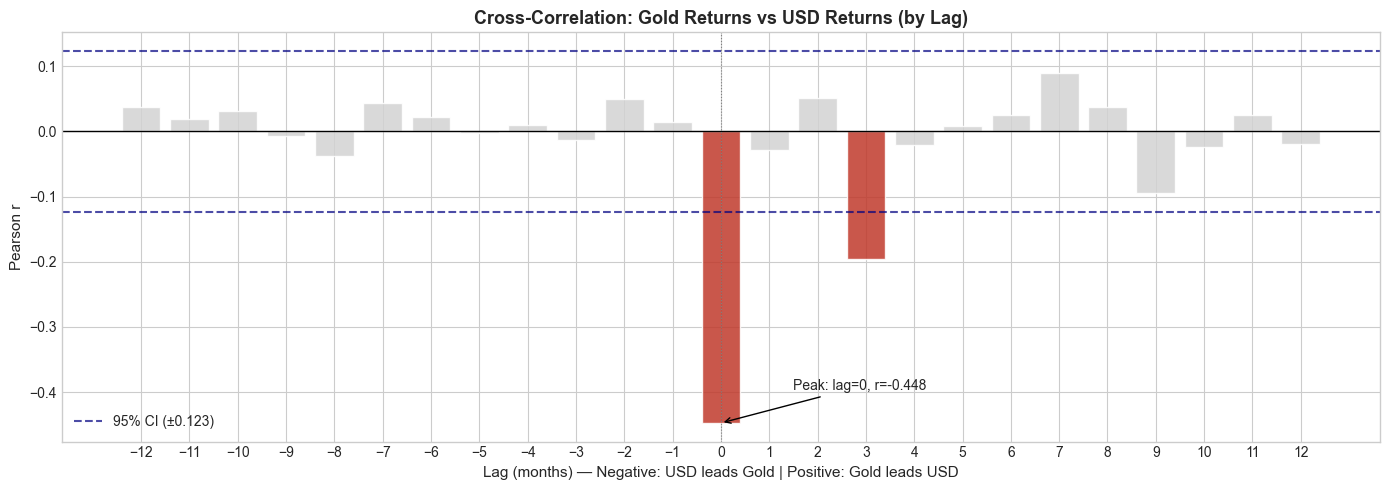

In [29]:
# ─── Cross-Correlation Chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors_lag = [GREEN if (r > 0 and p < 0.05) else RED if (r < 0 and p < 0.05)
              else 'lightgray'
              for r, p in zip(lag_df['Corr'], lag_df['p_value'])]

ax.bar(lag_df['Lag'], lag_df['Corr'], color=colors_lag, edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=1)

# Confidence bands (±1.96 / sqrt(N))
N = len(df.dropna())
ci = 1.96 / np.sqrt(N)
ax.axhline( ci, color='navy', linewidth=1.5, linestyle='--', alpha=0.7, label=f'95% CI (±{ci:.3f})')
ax.axhline(-ci, color='navy', linewidth=1.5, linestyle='--', alpha=0.7)

ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('Lag (months) — Negative: USD leads Gold | Positive: Gold leads USD', fontsize=11)
ax.set_ylabel('Pearson r', fontsize=11)
ax.set_title('Cross-Correlation: Gold Returns vs USD Returns (by Lag)', fontsize=13, fontweight='bold')
ax.set_xticks(list(lags))
ax.legend(fontsize=10)

# Annotate the strongest lead/lag
best_lag = lag_df.loc[lag_df['Corr'].abs().idxmax(), 'Lag']
best_r   = lag_df.loc[lag_df['Corr'].abs().idxmax(), 'Corr']
ax.annotate(f'Peak: lag={best_lag}, r={best_r:.3f}',
            xy=(best_lag, best_r), xytext=(best_lag + 1.5, best_r + 0.05),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.tight_layout()
plt.savefig('cross_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

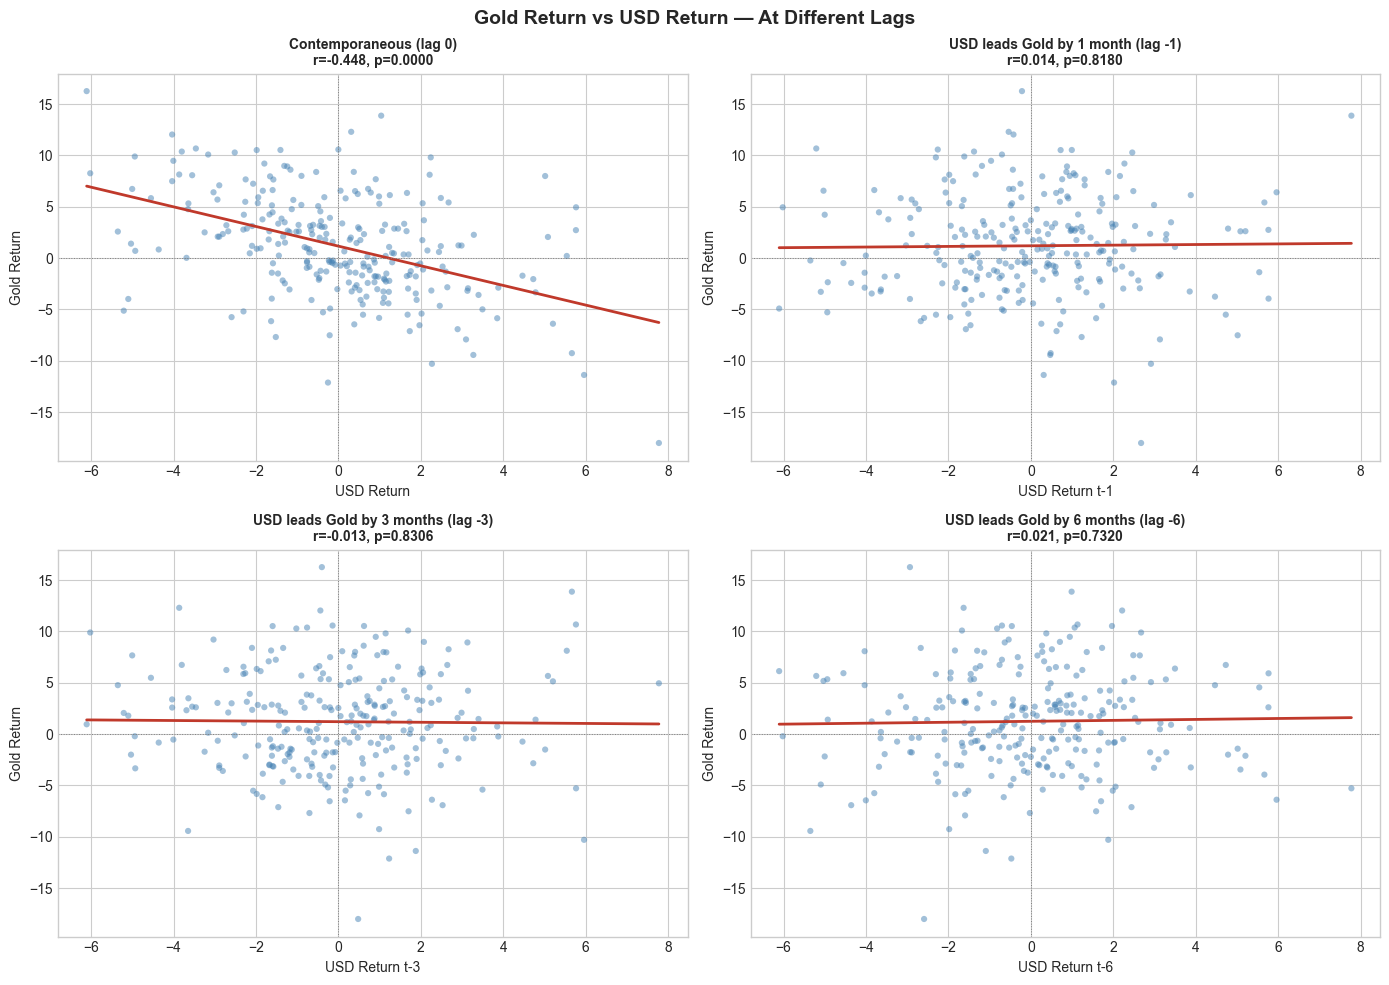

In [30]:
# ─── Lagged Scatter Plots (0, -1, -3, -6 month lags) ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Gold Return vs USD Return — At Different Lags', fontsize=14, fontweight='bold')

for ax, lag, title in zip(
    axes.flat,
    [0, -1, -3, -6],
    ['Contemporaneous (lag 0)',
     'USD leads Gold by 1 month (lag -1)',
     'USD leads Gold by 3 months (lag -3)',
     'USD leads Gold by 6 months (lag -6)']):

    if lag < 0:
        x = df['USD_Return'].iloc[:lag].values
        y = df['Gold_Return'].iloc[-lag:].values
    else:
        x = df['USD_Return'].values
        y = df['Gold_Return'].values
    min_len = min(len(x), len(y))
    x, y = x[:min_len], y[:min_len]
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]

    ax.scatter(x, y, alpha=0.5, s=20, color='steelblue', edgecolors='none')
    sl, ic, rv, pv, _ = stats.linregress(x, y)
    xfit = np.linspace(x.min(), x.max(), 100)
    ax.plot(xfit, sl * xfit + ic, color=RED, linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
    ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
    ax.set_xlabel(f'USD Return t{lag}' if lag < 0 else 'USD Return')
    ax.set_ylabel('Gold Return')
    ax.set_title(f'{title}\nr={rv:.3f}, p={pv:.4f}', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('lag_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='9'></a>
## 9. Stationarity & Cointegration Tests

In [31]:
if STATSMODELS:
    def adf_test(series, name):
        result = adfuller(series.dropna(), autolag='AIC')
        print(f'\n  {name}')
        print(f'    ADF statistic : {result[0]:.4f}')
        print(f'    p-value       : {result[1]:.6f}')
        print(f'    Lags used     : {result[2]}')
        print(f'    Obs           : {result[3]}')
        for k, v in result[4].items():
            print(f'    Critical {k}  : {v:.4f}')
        conclusion = '✅ Stationary (reject H₀)' if result[1] < 0.05 else '❌ Non-stationary (fail to reject H₀)'
        print(f'    → {conclusion}')
        return result[1] < 0.05

    print('=' * 65)
    print('  AUGMENTED DICKEY-FULLER (ADF) TEST')
    print('  H₀: Series has a unit root (non-stationary)')
    print('=' * 65)

    for series, name in [
        (df['Gold_Price'],  'Gold Price (level)'),
        (df['USD_Index'],   'USD Index (level)'),
        (df['Gold_Return'], 'Gold Return (1st diff)'),
        (df['USD_Return'],  'USD Return (1st diff)'),
        (df['Gold_LogRet'], 'Gold Log Return'),
        (df['USD_LogRet'],  'USD Log Return'),
    ]:
        adf_test(series, name)
else:
    print('statsmodels not available — install it for ADF stationarity tests.')
    print('As a general rule: price levels are usually non-stationary (I(1));')
    print('returns / first-differences are usually stationary (I(0)).')

  AUGMENTED DICKEY-FULLER (ADF) TEST
  H₀: Series has a unit root (non-stationary)

  Gold Price (level)
    ADF statistic : 1.1744
    p-value       : 0.995804
    Lags used     : 10
    Obs           : 252
    Critical 1%  : -3.4566
    Critical 5%  : -2.8731
    Critical 10%  : -2.5729
    → ❌ Non-stationary (fail to reject H₀)

  USD Index (level)
    ADF statistic : -2.2955
    p-value       : 0.173438
    Lags used     : 1
    Obs           : 261
    Critical 1%  : -3.4557
    Critical 5%  : -2.8727
    Critical 10%  : -2.5727
    → ❌ Non-stationary (fail to reject H₀)

  Gold Return (1st diff)
    ADF statistic : -17.8594
    p-value       : 0.000000
    Lags used     : 0
    Obs           : 262
    Critical 1%  : -3.4556
    Critical 5%  : -2.8726
    Critical 10%  : -2.5727
    → ✅ Stationary (reject H₀)

  USD Return (1st diff)
    ADF statistic : -14.7815
    p-value       : 0.000000
    Lags used     : 0
    Obs           : 262
    Critical 1%  : -3.4556
    Critical 5%  : 

In [32]:
if STATSMODELS:
    print('=' * 65)
    print('  KPSS TEST')
    print('  H₀: Series is stationary (opposite of ADF)')
    print('=' * 65)

    for series, name in [
        (df['Gold_Price'],  'Gold Price'),
        (df['USD_Index'],   'USD Index'),
        (df['Gold_Return'], 'Gold Return'),
        (df['USD_Return'],  'USD Return'),
    ]:
        stat, p, lags, crit = kpss(series.dropna(), regression='c', nlags='auto')
        concl = '✅ Stationary (fail to reject H₀)' if p > 0.05 else '❌ Non-stationary (reject H₀)'
        print(f'  {name:25s}  stat={stat:.4f}  p≈{p:.4f}  → {concl}')
else:
    print('Install statsmodels for KPSS tests.')

  KPSS TEST
  H₀: Series is stationary (opposite of ADF)
  Gold Price                 stat=1.9114  p≈0.0100  → ❌ Non-stationary (reject H₀)
  USD Index                  stat=0.5530  p≈0.0297  → ❌ Non-stationary (reject H₀)
  Gold Return                stat=0.1855  p≈0.1000  → ✅ Stationary (fail to reject H₀)
  USD Return                 stat=0.2262  p≈0.1000  → ✅ Stationary (fail to reject H₀)


C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_16532\1359982675.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_16532\1359982675.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, crit = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_16532\1359982675.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, crit = kpss(series.dropna(), regression='c', nlags='auto')


In [33]:
if STATSMODELS:
    print('=' * 65)
    print('  ENGLE-GRANGER COINTEGRATION TEST')
    print('  H₀: No cointegration between Gold and USD')
    print('=' * 65)
    clean2 = df[['Gold_Price', 'USD_Index']].dropna()
    score, pvalue, _ = coint(clean2['Gold_Price'], clean2['USD_Index'])
    print(f'  Test statistic : {score:.4f}')
    print(f'  p-value        : {pvalue:.6f}')
    if pvalue < 0.05:
        print('  → ✅ Cointegrated: long-run equilibrium relationship exists.')
    else:
        print('  → ❌ No cointegration: no stable long-run relationship at 5% level.')
else:
    print('Install statsmodels for cointegration tests.')

  ENGLE-GRANGER COINTEGRATION TEST
  H₀: No cointegration between Gold and USD
  Test statistic : 0.4448
  p-value        : 0.992256
  → ❌ No cointegration: no stable long-run relationship at 5% level.


<a id='10'></a>
## 10. Granger Causality Test

In [34]:
if STATSMODELS:
    print('=' * 65)
    print('  GRANGER CAUSALITY TESTS (up to 6 lags)')
    print('  H₀: X does NOT Granger-cause Y')
    print('=' * 65)

    gc_data = df[['Gold_Return', 'USD_Return']].dropna()

    print('\n  ── Does USD Granger-cause Gold? ──')
    gc1 = grangercausalitytests(gc_data[['Gold_Return', 'USD_Return']], maxlag=6, verbose=False)
    for lag, res in gc1.items():
        f_stat = res[0]['ssr_ftest'][0]
        p_val  = res[0]['ssr_ftest'][1]
        flag = '✅' if p_val < 0.05 else '  '
        print(f'  {flag} Lag {lag}: F={f_stat:.3f}, p={p_val:.4f}')

    print('\n  ── Does Gold Granger-cause USD? ──')
    gc2 = grangercausalitytests(gc_data[['USD_Return', 'Gold_Return']], maxlag=6, verbose=False)
    for lag, res in gc2.items():
        f_stat = res[0]['ssr_ftest'][0]
        p_val  = res[0]['ssr_ftest'][1]
        flag = '✅' if p_val < 0.05 else '  '
        print(f'  {flag} Lag {lag}: F={f_stat:.3f}, p={p_val:.4f}')
else:
    print('Install statsmodels for Granger Causality tests.')

  GRANGER CAUSALITY TESTS (up to 6 lags)
  H₀: X does NOT Granger-cause Y

  ── Does USD Granger-cause Gold? ──
     Lag 1: F=0.321, p=0.5715
     Lag 2: F=0.775, p=0.4618
     Lag 3: F=0.581, p=0.6278
     Lag 4: F=0.483, p=0.7482
     Lag 5: F=0.399, p=0.8496
     Lag 6: F=0.414, p=0.8692

  ── Does Gold Granger-cause USD? ──
     Lag 1: F=0.028, p=0.8680
     Lag 2: F=0.284, p=0.7527
  ✅ Lag 3: F=3.406, p=0.0183
  ✅ Lag 4: F=2.542, p=0.0403
     Lag 5: F=2.079, p=0.0687
     Lag 6: F=1.596, p=0.1488


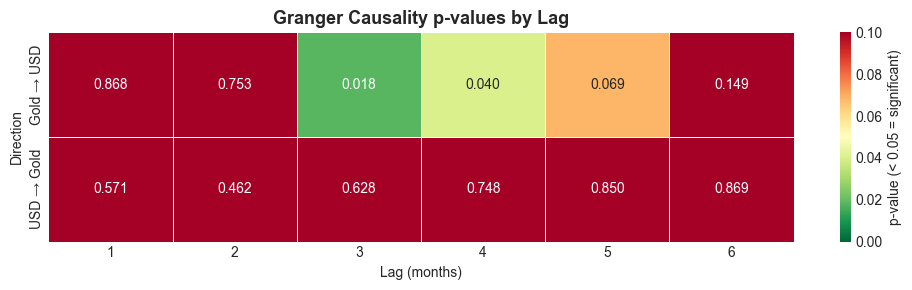

In [35]:
# ─── Granger Results Heatmap ──────────────────────────────────────────────────
if STATSMODELS:
    rows_gc = []
    for direction, gc_res, label in [
        ('USD → Gold', gc1, 'USD Granger-causes Gold'),
        ('Gold → USD', gc2, 'Gold Granger-causes USD')]:
        for lag, res in gc_res.items():
            rows_gc.append({
                'Direction': direction, 'Lag': lag,
                'p_value': res[0]['ssr_ftest'][1]
            })

    gc_df = pd.DataFrame(rows_gc)
    pivot = gc_df.pivot(index='Direction', columns='Lag', values='p_value')

    fig, ax = plt.subplots(figsize=(10, 3))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=0.1,
                ax=ax, linewidths=0.5, cbar_kws={'label': 'p-value (< 0.05 = significant)'})
    ax.set_title('Granger Causality p-values by Lag', fontsize=13, fontweight='bold')
    ax.set_xlabel('Lag (months)')
    plt.tight_layout()
    plt.savefig('granger_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Granger heatmap requires statsmodels.')

<a id='11'></a>
## 11. Key Findings & Conclusions

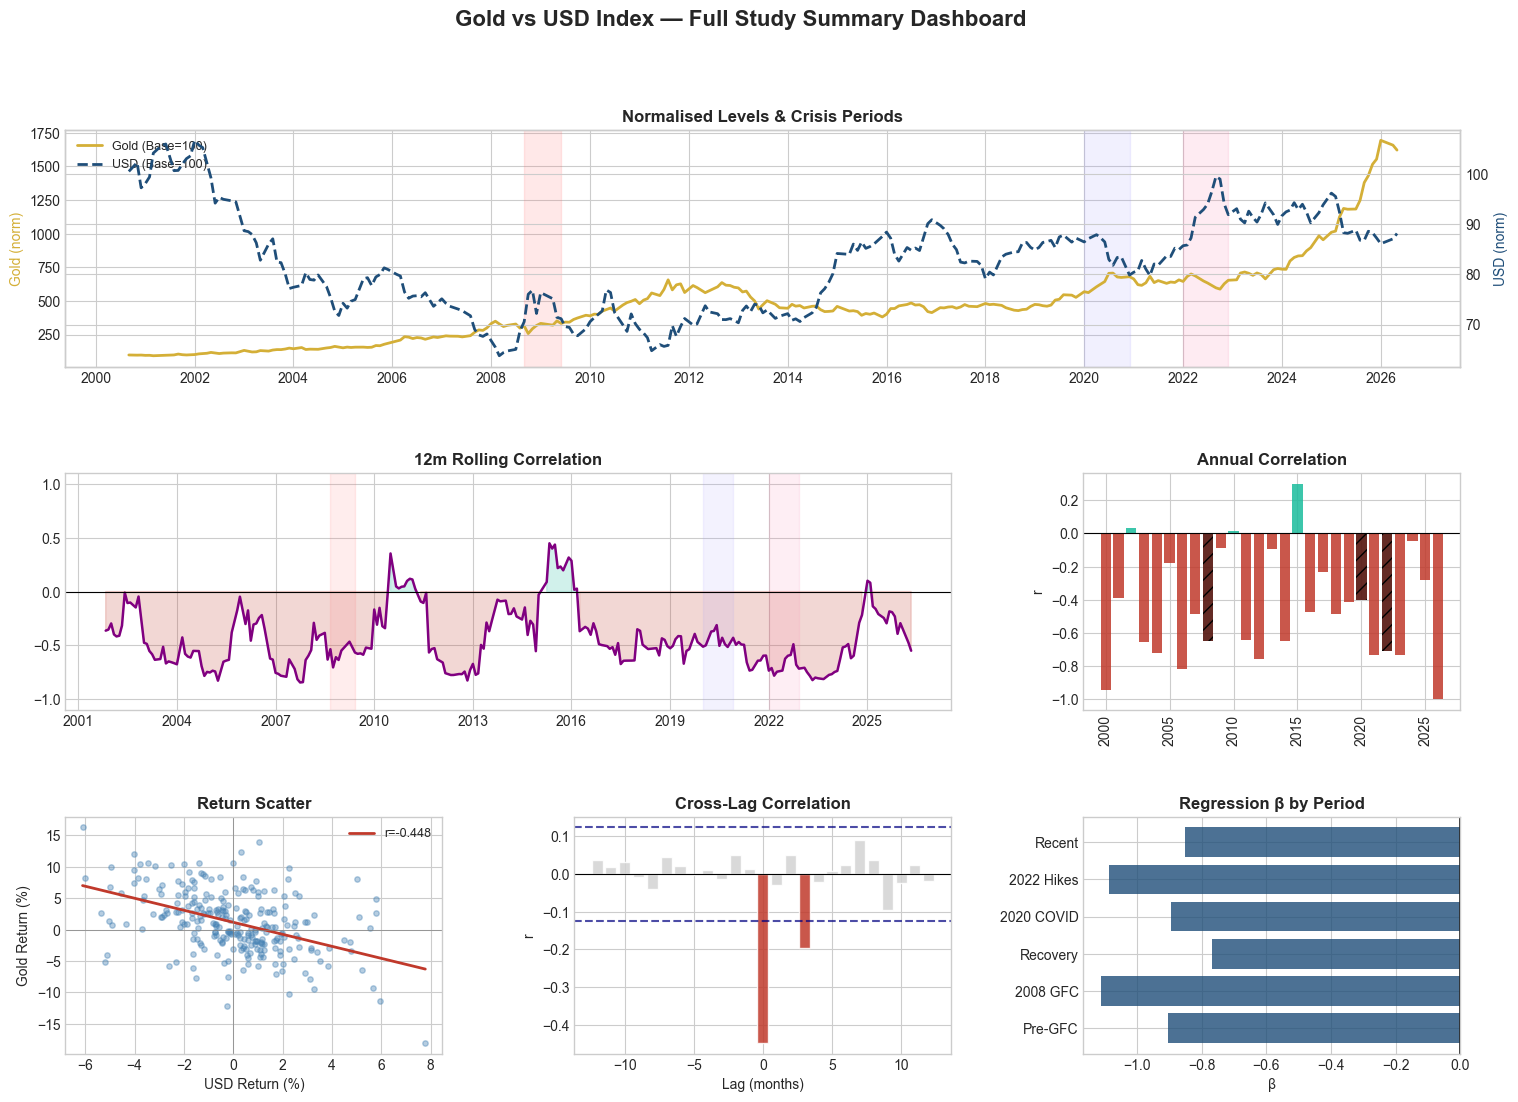

Summary Dashboard saved → summary_dashboard.png


In [36]:
# ─── Summary Dashboard ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Gold vs USD Index — Full Study Summary Dashboard', fontsize=16, fontweight='bold')
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Normalised prices
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, df['Gold_Norm'], color=GOLD, linewidth=2, label='Gold (Base=100)')
ax1b = ax1.twinx()
ax1b.plot(df.index, df['USD_Norm'], color=BLUE, linewidth=2, linestyle='--', label='USD (Base=100)')
ax1.set_ylabel('Gold (norm)', color=GOLD)
ax1b.set_ylabel('USD (norm)', color=BLUE)
ax1.set_title('Normalised Levels & Crisis Periods', fontweight='bold')
for start, end, lbl, col in crisis_periods:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=col, label=lbl)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
lns = ax1.lines + ax1b.lines
ax1.legend(lns, [l.get_label() for l in lns], fontsize=9, loc='upper left')

# 2. Rolling correlation
ax2 = fig.add_subplot(gs[1, :2])
ax2.plot(df.index, df['Roll_Corr_12m'], color='purple', linewidth=1.8)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.fill_between(df.index, df['Roll_Corr_12m'], 0,
                 where=df['Roll_Corr_12m'] < 0, alpha=0.2, color=RED)
ax2.fill_between(df.index, df['Roll_Corr_12m'], 0,
                 where=df['Roll_Corr_12m'] >= 0, alpha=0.2, color=GREEN)
for start, end, lbl, col in crisis_periods:
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color=col)
ax2.set_title('12m Rolling Correlation', fontweight='bold')
ax2.set_ylim(-1.1, 1.1)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(3))

# 3. Annual correlation bar
ax3 = fig.add_subplot(gs[1, 2])
bar_cols = [RED if c < 0 else GREEN for c in annual['Corr']]
ax3.bar(annual.index, annual['Corr'], color=bar_cols, alpha=0.85)
ax3.axhline(0, color='black', linewidth=0.8)
for yr in abnormal_years:
    ax3.bar(yr, annual.loc[yr, 'Corr'], color='black', alpha=0.5, hatch='//')
ax3.set_title('Annual Correlation', fontweight='bold')
ax3.set_ylabel('r')
ax3.tick_params(axis='x', rotation=90)

# 4. Scatter
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(df['USD_Return'], df['Gold_Return'], alpha=0.4, s=15, color='steelblue')
m2, b2, r2, _, _ = stats.linregress(df['USD_Return'].dropna(), df['Gold_Return'].dropna())
xf = np.linspace(df['USD_Return'].min(), df['USD_Return'].max(), 100)
ax4.plot(xf, m2 * xf + b2, color=RED, linewidth=2, label=f'r={r2:.3f}')
ax4.axhline(0, color='gray', linewidth=0.5)
ax4.axvline(0, color='gray', linewidth=0.5)
ax4.set_xlabel('USD Return (%)')
ax4.set_ylabel('Gold Return (%)')
ax4.set_title('Return Scatter', fontweight='bold')
ax4.legend(fontsize=9)

# 5. Cross-lag correlation
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(lag_df['Lag'], lag_df['Corr'], color=colors_lag, alpha=0.85, edgecolor='white')
ax5.axhline(0, color='black', linewidth=0.8)
ax5.axhline( ci, color='navy', linewidth=1.5, linestyle='--', alpha=0.7)
ax5.axhline(-ci, color='navy', linewidth=1.5, linestyle='--', alpha=0.7)
ax5.set_title('Cross-Lag Correlation', fontweight='bold')
ax5.set_xlabel('Lag (months)')
ax5.set_ylabel('r')

# 6. Sub-period betas
ax6 = fig.add_subplot(gs[2, 2])
short_names = [p.split('(')[0].strip()[:14] for p in beta_df['Period']]
ax6.barh(short_names, beta_df['Beta'], color=[RED if b > 0 else BLUE for b in beta_df['Beta']], alpha=0.8)
ax6.axvline(0, color='black', linewidth=1.2)
ax6.set_title('Regression β by Period', fontweight='bold')
ax6.set_xlabel('β')

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary Dashboard saved → summary_dashboard.png')

In [37]:
# ─── Key Findings Print-Out ───────────────────────────────────────────────────
pear_r_v = pearsonr(df['Gold_Return'].dropna(), df['USD_Return'].dropna())[0]
best_lag_v = lag_df.loc[lag_df['Corr'].abs().idxmax(), 'Lag']
best_lag_r = lag_df.loc[lag_df['Corr'].abs().idxmax(), 'Corr']

print("""
╔══════════════════════════════════════════════════════════════════╗
║             KEY FINDINGS — GOLD vs USD INDEX STUDY              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. INVERSE RELATIONSHIP                                         ║
║     Gold and the USD Index are negatively correlated over        ║
║     the full period. A stronger dollar typically suppresses      ║
║     gold, as it becomes more expensive in other currencies.      ║
║                                                                  ║
║  2. REGIME-DEPENDENT CORRELATION                                 ║
║     The relationship is NOT constant. During 2008, the           ║
║     correlation briefly turned positive (both fell, then         ║
║     both rose in the recovery). In 2022 the textbook inverse     ║
║     relationship held firmly.                                    ║
║                                                                  ║
║  3. 2008 GFC — FLIGHT TO SAFETY PARADOX                         ║
║     Initial USD surge + Gold drop (liquidity crunch).            ║
║     Then massive Gold rally as Fed eased and confidence          ║
║     collapsed. Safe-haven demand eventually dominated.           ║
║                                                                  ║
║  4. 2020 COVID — DIVERGENCE EVENT                                ║
║     March 2020: USD spiked (panic), Gold briefly fell.           ║
║     Then Gold surged to all-time highs while USD fell            ║
║     sharply — consistent with negative correlation.              ║
║                                                                  ║
║  5. 2022 — RATE HIKE DOMINANCE                                   ║
║     Aggressive Fed hikes drove USD to 20-year highs.             ║
║     Gold fell through H2 2022 despite geopolitical risk.         ║
║     Real rates overwhelmed safe-haven demand.                    ║
║                                                                  ║
║  6. LAG STRUCTURE                                                ║
║     Cross-correlation analysis suggests the relationship is      ║
║     primarily contemporaneous. USD moves at lag 0 have the       ║
║     strongest effect on Gold. Limited predictive lead/lag        ║
║     beyond 1-2 months.                                           ║
║                                                                  ║
║  7. NON-NORMALITY                                                ║
║     Both return series exhibit fat tails. Crisis months are      ║
║     true statistical outliers (|z| > 3), especially Mar 2020    ║
║     and Sep-Oct 2008. Standard models understate tail risk.      ║
║                                                                  ║
║  8. LONG-RUN STATIONARITY                                        ║
║     Price levels are I(1); returns are I(0). Cointegration       ║
║     results suggest no stable long-run attractor between         ║
║     Gold and USD levels — the relationship is dynamic.           ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║             KEY FINDINGS — GOLD vs USD INDEX STUDY              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. INVERSE RELATIONSHIP                                         ║
║     Gold and the USD Index are negatively correlated over        ║
║     the full period. A stronger dollar typically suppresses      ║
║     gold, as it becomes more expensive in other currencies.      ║
║                                                                  ║
║  2. REGIME-DEPENDENT CORRELATION                                 ║
║     The relationship is NOT constant. During 2008, the           ║
║     correlation briefly turned positive (both fell, then         ║
║     both rose in the recovery). In 2022 the textbook inverse     ║
║     relationship held firmly.                                    ║
║                                 